# Unet MedicalNet WarmUp Lr Encoder & Decoder

In [3]:
import os, math, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, EnsureTyped, Compose, SelectItemsd,
    NormalizeIntensityd, CropForegroundd, RandSpatialCropd,
    RandScaleIntensityd, RandShiftIntensityd, RandFlipd, ConcatItemsd, MapTransform
)
from monai.inferers import sliding_window_inference

def log(*a): print(*a, flush=True)

PROJECT_ROOT = Path().resolve()                    # selevel notebook
DATA_ROOT    = PROJECT_ROOT / "data"
# --- KONFIG ---
MAIN_DIR   = DATA_ROOT  # ganti path sesuai datasetmu
BATCH_SIZE = 1                                  # aman di T4 dengan patch 128^3
NUM_WORKERS= 2
ROI = (128, 128, 128)

/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [4]:
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_ROOT    = PROJECT_ROOT / "data"   # kamu bilang sekarang langsung "data"

def looks_like_patient_dir(p: Path) -> bool:
    if not p.is_dir(): return False
    need = ["flair","t1","t1ce","t2","seg"]
    found = 0
    for suf in need:
        if list(p.glob(f"*_{suf}.nii*")):
            found += 1
    return found == len(need)

def auto_find_main_dir(data_root: Path) -> str:
    # 1) data_root → apakah langsung berisi folder pasien?
    subs = [x for x in data_root.iterdir() if x.is_dir()]
    if any(looks_like_patient_dir(x) for x in subs):
        return str(data_root)
    # 2) satu tingkat di bawah
    for sub in subs:
        subs2 = [x for x in sub.iterdir() if x.is_dir()]
        if any(looks_like_patient_dir(x) for x in subs2):
            return str(sub)
    # 3) fallback: cari lebih dalam
    for sub in data_root.rglob("*"):
        if sub.is_dir():
            subs3 = [x for x in sub.iterdir() if x.is_dir()]
            if any(looks_like_patient_dir(x) for x in subs3):
                return str(sub)
    raise RuntimeError(f"Tidak menemukan folder pasien di bawah: {data_root}")

MAIN_DIR = auto_find_main_dir(DATA_ROOT)
print("MAIN_DIR =", MAIN_DIR)

# intip 1 folder pasien & isinya
sample_pat = next((d for d in Path(MAIN_DIR).iterdir() if d.is_dir()), None)
if sample_pat:
    print("Contoh folder pasien:", sample_pat.name)
    print("Contoh file:",
          [p.name for p in sample_pat.glob("*.nii*")])


MAIN_DIR = /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Contoh folder pasien: BraTS20_Training_115
Contoh file: ['BraTS20_Training_115_t1.nii', 'BraTS20_Training_115_seg.nii', 'BraTS20_Training_115_t2.nii', 'BraTS20_Training_115_flair.nii', 'BraTS20_Training_115_t1ce.nii']


In [5]:
def get_data_paths(data_dir):
    def find_file(folder, pid, suffix):
        for ext in (".nii.gz", ".nii"):
            p = os.path.join(folder, f"{pid}_{suffix}{ext}")
            if os.path.exists(p): return p
        return None

    data_paths = []
    print(f"Scanning dataset dir: {data_dir}")
    for pid in sorted(os.listdir(data_dir)):
        pdir = os.path.join(data_dir, pid)
        if not os.path.isdir(pdir): continue
        flair = find_file(pdir, pid, "flair")
        t1    = find_file(pdir, pid, "t1")
        t1gd  = find_file(pdir, pid, "t1ce")
        t2    = find_file(pdir, pid, "t2")
        seg   = find_file(pdir, pid, "seg")
        if all([flair, t1, t1gd, t2, seg]):
            data_paths.append({"flair":flair, "t1":t1, "t1gd":t1gd, "t2":t2, "label":seg, "pid":pid})
    print(f"Found {len(data_paths)} samples.")
    return data_paths

all_paths = get_data_paths(MAIN_DIR)
if not all_paths:
    raise RuntimeError("No data found. Check MAIN_DIR & filenames.")


Scanning dataset dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Found 368 samples.


In [4]:
class BraTSLabelToETTCWT(MapTransform):
    """
    Input d["label"] shape [1,D,H,W] atau [D,H,W] berisi {0,1,2,4}.
    Output d["label_ettcwt"] shape [3,D,H,W]: [ET, TC, WT] sebagai mask biner.
    """
    def __init__(self, keys=("label",), out_key="label_ettcwt"):
        super().__init__(keys); self.out_key = out_key

    def __call__(self, data):
        d = dict(data)
        lab = d[self.keys[0]]
        lab = torch.as_tensor(lab)
        if lab.ndim == 4 and lab.shape[0] == 1: lab = lab[0]  # [D,H,W]
        et = (lab == 4).float()
        tc = ((lab == 1) | (lab == 4)).float()
        wt = ((lab == 1) | (lab == 2) | (lab == 4)).float()
        d[self.out_key] = torch.stack([et, tc, wt], dim=0)  # [3,D,H,W]
        return d

In [5]:
P_RESCALE = 0.20
P_SHIFT   = 0.20
P_FLIP    = 0.50

train_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=True, random_size=False),
    # label → 3C multi-label
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
    # augmentasi B
    RandScaleIntensityd(keys="image", factors=0.1, prob=P_RESCALE),  # ×U[0.9,1.1]
    RandShiftIntensityd(keys="image", offsets=0.1, prob=P_SHIFT),    # +U[-0.1,0.1]
    RandFlipd(keys=["image","label_ettcwt"], prob=P_FLIP, spatial_axis=[0,1,2]),
])

val_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=False, random_size=False),
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
])


/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [6]:
class BraTSDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = list(items); self.tx = transform
        if not self.items: raise ValueError("Empty dataset")
    def __len__(self): return len(self.items)
    def __getitem__(self, i): 
        s = self.items[i]
        return self.tx(s) if self.tx else s

rng = np.random.RandomState(42)
perm = rng.permutation(len(all_paths))
all_paths = [all_paths[i] for i in perm]
cut = int(0.8*len(all_paths))
train_ds = BraTSDataset(all_paths[:cut], transform=train_transforms)
val_ds   = BraTSDataset(all_paths[cut:],  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

log(f"Loaders OK | train={len(train_ds)} val={len(val_ds)} bs={BATCH_SIZE}")

Loaders OK | train=294 val=74 bs=1


In [7]:
# ================================================
# UNet 3D + MedicalNet ResNet18 encoder (T4-friendly)
# Skip-connections sederhana ala pytorch-3dunet:
#   upsample -> concat(skip) -> TwoConv
# ================================================
import torch.nn as nn
import torch.nn.functional as F
from monai.networks.layers.factories import Conv
from monai.networks.nets.basic_unet import TwoConv, UpCat
import monai.networks.nets.resnet as monai_resnet


def prepare_medicalnet_state_for_monai(sd_in, in_channels=4):
    sd_raw = sd_in.get("state_dict", sd_in)
    sd = dict(sd_raw)
    remap = {}

    for k, v in sd.items():
        kk = k[len("module."):] if k.startswith("module.") else k

        # drop classifier
        if kk.startswith("fc."):
            continue

        # strip inner ".conv" (varian yang simpan conv submodule)
        kk = kk.replace(".conv1.conv.", ".conv1.")
        kk = kk.replace(".conv2.conv.", ".conv2.")
        kk = kk.replace(".conv3.conv.", ".conv3.")  # aman utk R50 juga

        # map style 'downsample.conv/bn' → 'downsample.0/1'
        kk = kk.replace(".downsample.conv.", ".downsample.0.")
        kk = kk.replace(".downsample.bn.",  ".downsample.1.")

        # map style 'shortcut' → 'downsample'
        kk = kk.replace(".shortcut.0.", ".downsample.0.")
        kk = kk.replace(".shortcut.1.", ".downsample.1.")

        # sebagian ckpt pakai 'downsample.weight' (tanpa .0) → asumsi conv
        if ".downsample.weight" in kk and ".downsample.0.weight" not in kk:
            kk = kk.replace(".downsample.weight", ".downsample.0.weight")
        if ".downsample.bias" in kk and ".downsample.0.bias" not in kk:
            kk = kk.replace(".downsample.bias", ".downsample.0.bias")

        remap[kk] = v

    # adapt conv1 Cin=1 → multi-modal (mis. 4)
    for conv1_key in ["conv1.weight", "conv1.conv.weight"]:
        if conv1_key in remap:
            w = remap[conv1_key]
            if w.ndim == 5 and w.shape[1] == 1 and in_channels > 1:
                w = w.mean(1, keepdim=True).repeat(1, in_channels, 1, 1, 1) / float(in_channels)
                remap[conv1_key] = w
                break

    return remap


@torch.no_grad()
def load_medicalnet_into_monai_resnet(backbone, pth_path, in_channels=4, verbose=True):
    raw = torch.load(pth_path, map_location="cpu")
    sd  = prepare_medicalnet_state_for_monai(raw, in_channels=in_channels)
    info = backbone.load_state_dict(sd, strict=False)
    try:
        missing, unexpected = info.missing_keys, info.unexpected_keys
    except AttributeError:
        missing, unexpected = info
    if verbose:
        monai_keys = backbone.state_dict()
        matched = sum(int(k in monai_keys and monai_keys[k].shape == sd[k].shape) for k in sd.keys())
        print(f"[MedicalNet→MONAI] matched={matched}  missing={len(missing)}  unexpected={len(unexpected)}")
    return info


class MedicalNetResNet18Encoder(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.backbone = monai_resnet.resnet18(
            spatial_dims=3, n_input_channels=in_channels, pretrained=False, progress=False
        )
        self.layer1 = self.backbone.layer1
        self.layer2 = self.backbone.layer2
        self.layer3 = self.backbone.layer3
        self.layer4 = self.backbone.layer4

    @torch.no_grad()
    def load_medicalnet_pretrain(self, pth_path, in_channels=4):
        load_medicalnet_into_monai_resnet(
            backbone=self.backbone, pth_path=pth_path, in_channels=in_channels, verbose=True
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x, inplace=True)
        s0 = x                 # <<< /2 tap (SEBELUM maxpool)
        x  = self.backbone.maxpool(x)
        s1 = self.layer1(x)    # /4
        s2 = self.layer2(s1)   # /8
        s3 = self.layer3(s2)   # /16
        # s4 = self.layer4(s3) # /32 (TIDAK dipakai di UNet++ 5-level)
        return s0, s1, s2, s3


class UNet3D_Decoder(nn.Module):
    """
    UNet 3D decoder dengan 4 tingkat skip dari encoder:
      - Input (/1) → conv_0_0 untuk memberi skip paling dangkal
      - Encoder taps: s0(~ /2), s1(~ /4), s2(~ /8), s3(~ /16)
    Alur:
      bottleneck(s3) → UpCat dengan s2 → UpCat dengan s1 → UpCat dengan s0 → UpCat dengan x_0_0 → head
    """
    def __init__(
        self,
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        # fitur kecil agar muat di T4 (sesuaikan bila VRAM longgar)
        features=(16, 32, 64, 128, 128),  # F0, F1, F2, F3, F4(bottleneck)
        act=("LeakyReLU", {"negative_slope": 0.1, "inplace": True}),
        norm=("instance", {"affine": True}),
        dropout=0.0,
        upsample="nontrainable",          # hemat VRAM
        enc_channels=(64, 128, 256, 512), # taps ResNet18
        deep_supervision=False,           # default UNet: single head
    ):
        super().__init__()
        self.deep_supervision = deep_supervision
        F0, F1, F2, F3, F4 = features

        # Adaptasi channel skip dari encoder → dim UNet
        Conv1x1 = lambda a, b: Conv["conv", spatial_dims](a, b, kernel_size=1, bias=False)
        self.adapt_s0 = Conv1x1(enc_channels[0], F1)  # /2
        self.adapt_s1 = Conv1x1(enc_channels[1], F2)  # /4
        self.adapt_s2 = Conv1x1(enc_channels[2], F3)  # /8
        self.adapt_s3 = Conv1x1(enc_channels[3], F4)  # /16 (bottleneck in)

        # Blok paling dangkal di resolusi /1 (untuk skip terakhir)
        self.conv_0_0 = TwoConv(spatial_dims, in_channels, F0, act, norm, bias=True, dropout=dropout)

        # Bottleneck pada /16
        self.bottleneck = TwoConv(spatial_dims, F4, F4, act, norm, bias=True, dropout=dropout)

        # Up-sampling ladder (trilinear → concat → TwoConv)
        # /16 → /8
        self.up_3 = UpCat(spatial_dims, F4, F3, F3, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /8 → /4
        self.up_2 = UpCat(spatial_dims, F3, F2, F2, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /4 → /2
        self.up_1 = UpCat(spatial_dims, F2, F1, F1, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /2 → /1 (skip dengan x_0_0)
        # NOTE: halves=False agar channels skip + up sama persis
        self.up_0 = UpCat(spatial_dims, F1, F0, F0, act, norm, bias=True, dropout=dropout,
                           upsample=upsample, halves=False)

        # Head
        self.head = Conv["conv", spatial_dims](F0, out_channels, kernel_size=1)

        # (opsional) heads untuk deep supervision jika ingin dihidupkan
        if self.deep_supervision:
            self.ds2 = Conv["conv", spatial_dims](F1, out_channels, kernel_size=1)  # /2
            self.ds3 = Conv["conv", spatial_dims](F2, out_channels, kernel_size=1)  # /4
            self.ds4 = Conv["conv", spatial_dims](F3, out_channels, kernel_size=1)  # /8

    def forward(self, x, feats):
        """
        x: input citra [B, C, D, H, W] (resolusi /1)
        feats: (s0, s1, s2, s3) dari encoder ResNet18 (kira-kira /2, /4, /8, /16)
        """
        s0, s1, s2, s3 = feats

        # Normalisasi spasial → tepat /2,/4,/8,/16 dari ukuran input setelah conv_0_0
        x_0_0 = self.conv_0_0(x)   # /1
        D, H, W = x_0_0.shape[2:]
        size_1  = (max(1, D // 2),  max(1, H // 2),  max(1, W // 2))   # /2
        size_2  = (max(1, D // 4),  max(1, H // 4),  max(1, W // 4))   # /4
        size_3  = (max(1, D // 8),  max(1, H // 8),  max(1, W // 8))   # /8
        size_4  = (max(1, D // 16), max(1, H // 16), max(1, W // 16))  # /16

        # Adapt channel lalu *force* ke ukuran yang konsisten
        s0 = F.interpolate(self.adapt_s0(s0), size=size_1, mode="trilinear", align_corners=False)
        s1 = F.interpolate(self.adapt_s1(s1), size=size_2, mode="trilinear", align_corners=False)
        s2 = F.interpolate(self.adapt_s2(s2), size=size_3, mode="trilinear", align_corners=False)
        s3 = F.interpolate(self.adapt_s3(s3), size=size_4, mode="trilinear", align_corners=False)

        # Bottleneck (/16)
        x_3 = self.bottleneck(s3)

        # Naik tangga UNet
        x_2 = self.up_3(x_3, s2)              # /8
        x_1 = self.up_2(x_2, s1)              # /4
        x_0_5 = self.up_1(x_1, s0)            # /2
        x_out = self.up_0(x_0_5, x_0_0)       # /1

        y = self.head(x_out)

        if not self.deep_supervision:
            return y

        # Deep supervision (opsional): kembalikan beberapa prediksi multi-scale
        y_ds2 = self.ds2(x_0_5)  # /2
        y_ds3 = self.ds3(x_1)    # /4
        y_ds4 = self.ds4(x_2)    # /8
        # urutan: finest → coarser (selaras dgn pola Anda)
        return [y, y_ds2, y_ds3, y_ds4]


class UNet3D_MedicalNet(nn.Module):
    """
    Wrapper: ResNet18 3D (MedicalNet) sebagai encoder + UNet decoder klasik.
    Output channels default=3 (ET/TC/WT) → gunakan sigmoid di loss (multi-label).
    """
    def __init__(
        self,
        in_channels=4,
        out_channels=3,
        features=(16, 32, 64, 128, 128),
        enc_channels=(64, 128, 256, 512),
        deep_supervision=False,
    ):
        super().__init__()
        self.encoder = MedicalNetResNet18Encoder(in_channels=in_channels)
        self.decoder = UNet3D_Decoder(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            enc_channels=enc_channels,
            upsample="nontrainable",
            deep_supervision=deep_supervision,
        )

    def load_medicalnet(self, pth_path):
        """
        pth_path: path ke weight MedicalNet (mis: resnet_18_23dataset.pth)
        """
        self.encoder.load_medicalnet_pretrain(
            pth_path=pth_path,
            in_channels=self.encoder.backbone.conv1.in_channels,
        )

    def forward(self, x):
        feats = self.encoder(x)      # (s0, s1, s2, s3)
        return self.decoder(x, feats)


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet3D_MedicalNet(
        in_channels=4,            # FLAIR,T1,T1ce,T2
        out_channels=3,           # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128),
        enc_channels=(64, 64, 128, 256),
        deep_supervision=True,  # kecilkan jika VRAM mepet: (32,64,128,256,256,32)
    ).to("cuda")

# path MedicalNet (.pth) dari "Models" Kaggle (pakai pencari kalau perlu)
PROJECT_ROOT = Path().resolve()  # folder tempat notebook berada
MEDNET_PTH   = PROJECT_ROOT / "Pretrained" / "resnet_18_23dataset.pth"
model.load_medicalnet(MEDNET_PTH)

/tmp/ipykernel_3468996/622822728.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pth_path, map_location="cpu")


[MedicalNet→MONAI] matched=102  missing=20  unexpected=0


In [9]:
# === setelah model di-instansiasi & (opsional) load bobot ===
# model = UNetPP3D_MedicalNet(...).cuda()
# model.load_medicalnet(MEDNET_PTH)

import torch
import torch.nn as nn

def init_identity_downsample(block_down, in_ch, out_ch, stride=2):
    """
    block_down: nn.Sequential(conv1x1, bn)
    Set conv 1x1 jadi 'copy channel' (diagonal) dgn stride sesuai, BN -> γ=1, β=0, running stats reset.
    """
    conv = block_down[0]; bn = block_down[1]
    assert isinstance(conv, nn.Conv3d) and isinstance(bn, (nn.BatchNorm3d, nn.SyncBatchNorm)), \
        "Ekspektasi downsample = [Conv3d, BatchNorm3d]"

    # nolkan dulu, lalu isi diagonal agar menyalin channel sebanyak min(in_ch, out_ch)
    nn.init.zeros_(conv.weight)
    if conv.bias is not None:
        nn.init.zeros_(conv.bias)
    c = min(in_ch, out_ch)
    with torch.no_grad():
        for i in range(c):
            conv.weight[i, i, 0, 0, 0] = 1.0

    # BN ke identitas
    nn.init.ones_(bn.weight)
    nn.init.zeros_(bn.bias)
    bn.running_mean.zero_()
    bn.running_var.fill_(1)

def reinit_missing_downsamples_resnet18(backbone):
    # R18 taps: layer2.0, layer3.0, layer4.0 masing-masing punya downsample (stride=2)
    init_identity_downsample(backbone.layer2[0].downsample, in_ch=64,  out_ch=128, stride=2)
    init_identity_downsample(backbone.layer3[0].downsample, in_ch=128, out_ch=256, stride=2)
    init_identity_downsample(backbone.layer4[0].downsample, in_ch=256, out_ch=512, stride=2)

# PANGGIL DI SINI (setelah load pretrained)
reinit_missing_downsamples_resnet18(model.encoder.backbone)

# (opsional) cepat cek satu nilai diagonal untuk memastikan terisi:
print("diag l2:", model.encoder.backbone.layer2[0].downsample[0].weight[0,0,0,0,0].item())


diag l2: 1.0


In [10]:
for m in model.encoder.backbone.modules():
    if isinstance(m, (nn.BatchNorm3d, nn.SyncBatchNorm)):
        m.eval()

In [11]:
def dice_per_region(pred_bin, lab_bin, eps=1e-6):
    # pred_bin & lab_bin: [B,3,D,H,W] biner
    dims = (0,2,3,4)
    inter = (pred_bin * lab_bin).sum(dim=dims)                  # [3]
    den   = pred_bin.sum(dim=dims) + lab_bin.sum(dim=dims)      # [3]
    return (2*inter + eps) / (den + eps)  

In [12]:
import torch
import torch.nn.functional as F

def _resize_to_target(o: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # Samakan spatial size prediksi ke label (D,H,W) jika berbeda
    if o.shape[2:] != target.shape[2:]:
        o = F.interpolate(o, size=target.shape[2:], mode="trilinear", align_corners=False)
    return o

def multilabel_dice_loss(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    logits = _resize_to_target(logits, target)    # <<< kunci Opsi A
    probs = torch.sigmoid(logits)
    dims = (0, 2, 3, 4)                           # batch + spatial, per-channel dice
    inter = (probs * target).sum(dims)
    den   = probs.sum(dims) + target.sum(dims)
    dice  = (2 * inter + eps) / (den + eps)
    return 1.0 - dice.mean()

def ds_loss(outputs, target, weights=None):
    # Mendukung: single output atau list/tuple (deep supervision)
    if isinstance(outputs, (list, tuple)):
        if weights is None:
            # Konsisten untuk 4 head (bisa dipangkas sesuai jumlah head aktual)
            weights = [1.0, 0.5, 0.25, 0.125][:len(outputs)]
        losses = [w * multilabel_dice_loss(o, target) for o, w in zip(outputs, weights)]
        return sum(losses) / sum(weights)
    return multilabel_dice_loss(outputs, target)


In [13]:
def split_wd(named_params):
    decay, no_decay = [], []
    for n,p in named_params:
        if not p.requires_grad: continue
        if p.ndim == 1 or n.endswith(".bias"):
            no_decay.append(p)      # norm & bias
        else:
            decay.append(p)
    return [{"params":decay, "weight_decay":1e-2},
            {"params":no_decay, "weight_decay":0.0}]

enc_groups = split_wd(model.encoder.named_parameters())
dec_groups = split_wd(model.decoder.named_parameters())

optimizer = torch.optim.AdamW(
    [
        {**enc_groups[0], "lr":1e-4},  # encoder w/ decay
        {**enc_groups[1], "lr":1e-4},  # encoder no-decay
        {**dec_groups[0], "lr":2e-4},  # decoder w/ decay
        {**dec_groups[1], "lr":2e-4},  # decoder no-decay
    ]
)

def make_cosine_with_warmup(optimizer, warmup_epochs=5, max_epochs=200):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch+1)/float(max(1,warmup_epochs))
        t = (epoch - warmup_epochs)/float(max(1,max_epochs-warmup_epochs))
        return 0.5*(1.0 + math.cos(math.pi*t))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

MAX_EPOCHS = 200
scheduler  = make_cosine_with_warmup(optimizer, warmup_epochs=5, max_epochs=MAX_EPOCHS)

In [ ]:
from tqdm import tqdm
from torch.amp import autocast
import time

# --- helper agar aman jika output berupa list/tuple (ambil head utama) ---
def _ensure_tensor(o):
    return o[0] if isinstance(o, (list, tuple)) else o

scaler = GradScaler(enabled=True)
device = "cuda"
early_patience = 20
best_val = float("inf"); bad = 0
best_state = None

# stabilkan BN encoder (batch kecil)
for m in model.encoder.modules():
    if isinstance(m, (torch.nn.BatchNorm3d, torch.nn.SyncBatchNorm)):
        m.eval()

for epoch in range(MAX_EPOCHS):
    model.train()
    tr = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [train]", leave=False)
    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)                 # [B,4,D,H,W]
        lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            out = model(img)                   # bisa tensor atau list (DS)
            loss = ds_loss(out, lab)           # ds_loss kita sudah handle list/tensor
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()

        tr += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    tr /= max(1, len(train_loader))

    # ---- validation (sliding window) ----
    model.eval()
    va = 0.0
    dice_sums = torch.zeros(3, device=device)  # akumulasi Dice ET/TC/WT
    n_batches  = 0
    
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [val]", leave=False)
    with torch.no_grad():
        for batch in pbar_val:
            img = batch["image"].to(device, non_blocking=True)
            lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]
    
            with autocast("cuda"):
                logits = sliding_window_inference(
                    img, roi_size=ROI, sw_batch_size=1,
                    predictor=model, overlap=0.5, mode="gaussian"
                )
                logits = _ensure_tensor(logits)          # <-- penting: pastikan tensor utama
                loss = multilabel_dice_loss(logits, lab) # aman (full-res/no-op resize untuk UNet++)
            va += loss.item(); n_batches += 1
    
            # --- METRICS: Dice per region ---
            probs = torch.sigmoid(logits)
            pred_bin = (probs > 0.5).float()
            lab_bin  = (lab   > 0.5).float()
            dice_cls = dice_per_region(pred_bin, lab_bin)  # [ET,TC,WT]
            dice_sums += dice_cls
    
            # tampilkan di progress bar (mean sementara)
            dice_tmp = (dice_sums / n_batches).detach().cpu().tolist()
            pbar_val.set_postfix(val_loss=f"{loss.item():.4f}",
                                 dice=f"ET:{dice_tmp[0]:.3f}|TC:{dice_tmp[1]:.3f}|WT:{dice_tmp[2]:.3f}")
    
    va /= max(1, n_batches)
    
    # ringkas Dice epoch
    dice_mean_per_cls = (dice_sums / max(1, n_batches)).detach().cpu().tolist()  # [ET,TC,WT]
    dice_mean = float(sum(dice_mean_per_cls)/3.0)
    names = ["ET","TC","WT"]
    dice_str = " | ".join(f"{n}:{v:.3f}" for n,v in zip(names, dice_mean_per_cls))
    
    log(f"[{epoch+1:03d}/{MAX_EPOCHS}] train={tr:.4f}  val={va:.4f}  Dice(mean)={dice_mean:.3f} ({dice_str})")

    scheduler.step()

    if va < best_val - 1e-6:
        best_val = va; bad = 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= early_patience:
            log(f"Early stop at {epoch+1}, best val={best_val:.4f}")
            break

CKPT_DIR = Path().resolve() / "checkpoints_unet_LR"   # folder sejajar notebook
CKPT_DIR.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d-%H%M%S")
best_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_best_{stamp}.pt"
last_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_last_{stamp}.pt"

# simpan BEST (berdasarkan val loss)
if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    torch.save(model.state_dict(), best_path)
    log("saved BEST:", str(best_path))

# simpan LAST (state setelah epoch terakhir) — opsional tapi berguna untuk resume cepat
torch.save(model.state_dict(), last_path)
log("saved LAST:", str(last_path))

# (opsional) simpan checkpoint lengkap utk resume (model+optim+sched+scaler)
full_ckpt_path = CKPT_DIR / f"checkpoint_full_{stamp}.pt"
torch.save({
    "epoch": epoch + 1,
    "best_val": best_val,
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "scaler": scaler.state_dict(),
}, full_ckpt_path)
log("saved FULL checkpoint:", str(full_ckpt_path))



/tmp/ipykernel_3468996/3052706800.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
Epoch 1/200 [train]:   0%|          | 0/294 [00:00<?, ?it/s]

[001/200] train=0.9180  val=0.9207  Dice(mean)=0.096 (ET:0.028 | TC:0.089 | WT:0.170)


[002/200] train=0.8992  val=0.9083  Dice(mean)=0.151 (ET:0.047 | TC:0.088 | WT:0.316)


[003/200] train=0.8652  val=0.8924  Dice(mean)=0.314 (ET:0.050 | TC:0.388 | WT:0.505)


[004/200] train=0.8052  val=0.8668  Dice(mean)=0.333 (ET:0.061 | TC:0.443 | WT:0.495)


...

[050/200] train=0.1751  val=0.1706  Dice(mean)=0.835 (ET:0.815 | TC:0.797 | WT:0.895)


[051/200] train=0.1727  val=0.1695  Dice(mean)=0.832 (ET:0.783 | TC:0.812 | WT:0.901)


[052/200] train=0.1711  val=0.1664  Dice(mean)=0.835 (ET:0.795 | TC:0.809 | WT:0.901)


[053/200] train=0.1683  val=0.1555  Dice(mean)=0.846 (ET:0.805 | TC:0.839 | WT:0.895)
Early stop at 53, best val=0.1554


saved BEST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet/unetpp_medicalnet_multilabel_best_20251013-024333.pt
saved LAST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet/unetpp_medicalnet_multilabel_last_20251013-024333.pt
saved FULL checkpoint: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet/checkpoint_full_20251013-024333.pt


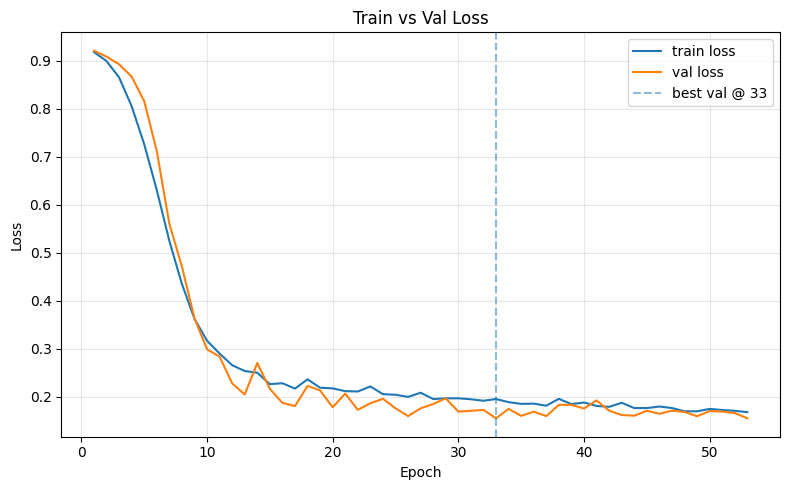

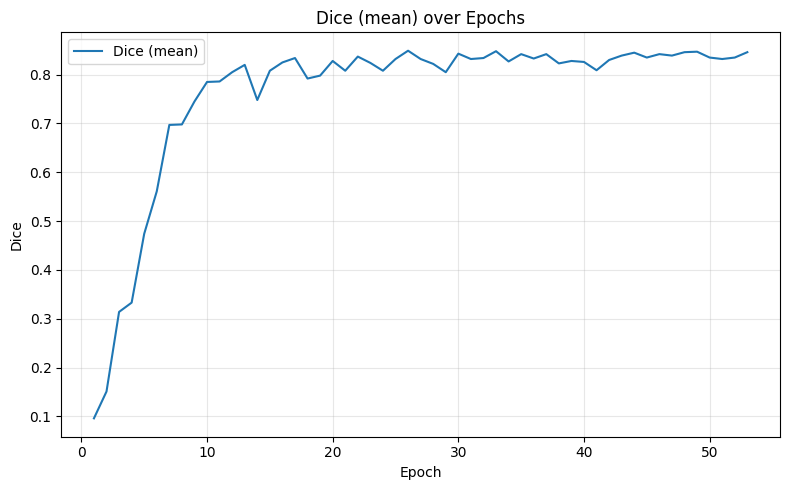

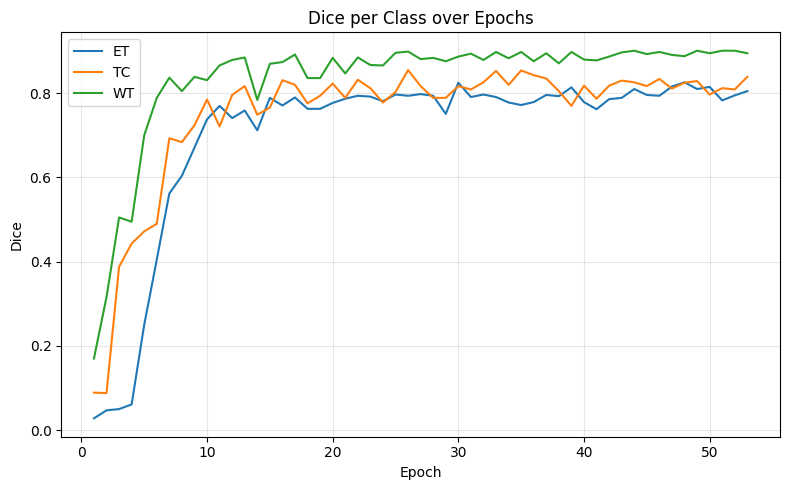

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ganti path sesuai lokasi file kamu
df = pd.read_csv("ReportHasil/Unet_warmupLR.csv").sort_values("epoch")

best_idx = df["val_loss"].idxmin()
best_epoch = int(df.loc[best_idx, "epoch"])

# Loss
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="train loss")
plt.plot(df["epoch"], df["val_loss"], label="val loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.5, label=f"best val @ {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Val Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice (mean)
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_mean"], label="Dice (mean)")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice (mean) over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice per kelas
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_et"], label="ET")
plt.plot(df["epoch"], df["dice_tc"], label="TC")
plt.plot(df["epoch"], df["dice_wt"], label="WT")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice per Class over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


# Unet MedicalNet WarmUp Freeze Encoder & warmup LR Decoder

In [1]:
import os, math, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, EnsureTyped, Compose, SelectItemsd,
    NormalizeIntensityd, CropForegroundd, RandSpatialCropd,
    RandScaleIntensityd, RandShiftIntensityd, RandFlipd, ConcatItemsd, MapTransform
)
from monai.inferers import sliding_window_inference

def log(*a): print(*a, flush=True)

PROJECT_ROOT = Path().resolve()                    # selevel notebook
DATA_ROOT    = PROJECT_ROOT / "data"
# --- KONFIG ---
MAIN_DIR   = DATA_ROOT  # ganti path sesuai datasetmu
BATCH_SIZE = 1                                  # aman di T4 dengan patch 128^3
NUM_WORKERS= 2
ROI = (128, 128, 128)

/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_ROOT    = PROJECT_ROOT / "data"   # kamu bilang sekarang langsung "data"

def looks_like_patient_dir(p: Path) -> bool:
    if not p.is_dir(): return False
    need = ["flair","t1","t1ce","t2","seg"]
    found = 0
    for suf in need:
        if list(p.glob(f"*_{suf}.nii*")):
            found += 1
    return found == len(need)

def auto_find_main_dir(data_root: Path) -> str:
    # 1) data_root → apakah langsung berisi folder pasien?
    subs = [x for x in data_root.iterdir() if x.is_dir()]
    if any(looks_like_patient_dir(x) for x in subs):
        return str(data_root)
    # 2) satu tingkat di bawah
    for sub in subs:
        subs2 = [x for x in sub.iterdir() if x.is_dir()]
        if any(looks_like_patient_dir(x) for x in subs2):
            return str(sub)
    # 3) fallback: cari lebih dalam
    for sub in data_root.rglob("*"):
        if sub.is_dir():
            subs3 = [x for x in sub.iterdir() if x.is_dir()]
            if any(looks_like_patient_dir(x) for x in subs3):
                return str(sub)
    raise RuntimeError(f"Tidak menemukan folder pasien di bawah: {data_root}")

MAIN_DIR = auto_find_main_dir(DATA_ROOT)
print("MAIN_DIR =", MAIN_DIR)

# intip 1 folder pasien & isinya
sample_pat = next((d for d in Path(MAIN_DIR).iterdir() if d.is_dir()), None)
if sample_pat:
    print("Contoh folder pasien:", sample_pat.name)
    print("Contoh file:",
          [p.name for p in sample_pat.glob("*.nii*")])


MAIN_DIR = /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Contoh folder pasien: BraTS20_Training_115
Contoh file: ['BraTS20_Training_115_t1.nii', 'BraTS20_Training_115_seg.nii', 'BraTS20_Training_115_t2.nii', 'BraTS20_Training_115_flair.nii', 'BraTS20_Training_115_t1ce.nii']


In [4]:
def get_data_paths(data_dir):
    def find_file(folder, pid, suffix):
        for ext in (".nii.gz", ".nii"):
            p = os.path.join(folder, f"{pid}_{suffix}{ext}")
            if os.path.exists(p): return p
        return None

    data_paths = []
    print(f"Scanning dataset dir: {data_dir}")
    for pid in sorted(os.listdir(data_dir)):
        pdir = os.path.join(data_dir, pid)
        if not os.path.isdir(pdir): continue
        flair = find_file(pdir, pid, "flair")
        t1    = find_file(pdir, pid, "t1")
        t1gd  = find_file(pdir, pid, "t1ce")
        t2    = find_file(pdir, pid, "t2")
        seg   = find_file(pdir, pid, "seg")
        if all([flair, t1, t1gd, t2, seg]):
            data_paths.append({"flair":flair, "t1":t1, "t1gd":t1gd, "t2":t2, "label":seg, "pid":pid})
    print(f"Found {len(data_paths)} samples.")
    return data_paths

all_paths = get_data_paths(MAIN_DIR)
if not all_paths:
    raise RuntimeError("No data found. Check MAIN_DIR & filenames.")


Scanning dataset dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Found 368 samples.


In [5]:
class BraTSLabelToETTCWT(MapTransform):
    """
    Input d["label"] shape [1,D,H,W] atau [D,H,W] berisi {0,1,2,4}.
    Output d["label_ettcwt"] shape [3,D,H,W]: [ET, TC, WT] sebagai mask biner.
    """
    def __init__(self, keys=("label",), out_key="label_ettcwt"):
        super().__init__(keys); self.out_key = out_key

    def __call__(self, data):
        d = dict(data)
        lab = d[self.keys[0]]
        lab = torch.as_tensor(lab)
        if lab.ndim == 4 and lab.shape[0] == 1: lab = lab[0]  # [D,H,W]
        et = (lab == 4).float()
        tc = ((lab == 1) | (lab == 4)).float()
        wt = ((lab == 1) | (lab == 2) | (lab == 4)).float()
        d[self.out_key] = torch.stack([et, tc, wt], dim=0)  # [3,D,H,W]
        return d

In [6]:
P_RESCALE = 0.20
P_SHIFT   = 0.20
P_FLIP    = 0.50

train_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=True, random_size=False),
    # label → 3C multi-label
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
    # augmentasi B
    RandScaleIntensityd(keys="image", factors=0.1, prob=P_RESCALE),  # ×U[0.9,1.1]
    RandShiftIntensityd(keys="image", offsets=0.1, prob=P_SHIFT),    # +U[-0.1,0.1]
    RandFlipd(keys=["image","label_ettcwt"], prob=P_FLIP, spatial_axis=[0,1,2]),
])

val_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=False, random_size=False),
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
])


/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [7]:
class BraTSDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = list(items); self.tx = transform
        if not self.items: raise ValueError("Empty dataset")
    def __len__(self): return len(self.items)
    def __getitem__(self, i): 
        s = self.items[i]
        return self.tx(s) if self.tx else s

rng = np.random.RandomState(42)
perm = rng.permutation(len(all_paths))
all_paths = [all_paths[i] for i in perm]
cut = int(0.8*len(all_paths))
train_ds = BraTSDataset(all_paths[:cut], transform=train_transforms)
val_ds   = BraTSDataset(all_paths[cut:],  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

log(f"Loaders OK | train={len(train_ds)} val={len(val_ds)} bs={BATCH_SIZE}")

Loaders OK | train=294 val=74 bs=1


In [8]:
# ================================================
# UNet 3D + MedicalNet ResNet18 encoder (T4-friendly)
# Skip-connections sederhana ala pytorch-3dunet:
#   upsample -> concat(skip) -> TwoConv
# ================================================
import torch.nn as nn
import torch.nn.functional as F
from monai.networks.layers.factories import Conv
from monai.networks.nets.basic_unet import TwoConv, UpCat
import monai.networks.nets.resnet as monai_resnet


def prepare_medicalnet_state_for_monai(sd_in, in_channels=4):
    sd_raw = sd_in.get("state_dict", sd_in)
    sd = dict(sd_raw)
    remap = {}

    for k, v in sd.items():
        kk = k[len("module."):] if k.startswith("module.") else k

        # drop classifier
        if kk.startswith("fc."):
            continue

        # strip inner ".conv" (varian yang simpan conv submodule)
        kk = kk.replace(".conv1.conv.", ".conv1.")
        kk = kk.replace(".conv2.conv.", ".conv2.")
        kk = kk.replace(".conv3.conv.", ".conv3.")  # aman utk R50 juga

        # map style 'downsample.conv/bn' → 'downsample.0/1'
        kk = kk.replace(".downsample.conv.", ".downsample.0.")
        kk = kk.replace(".downsample.bn.",  ".downsample.1.")

        # map style 'shortcut' → 'downsample'
        kk = kk.replace(".shortcut.0.", ".downsample.0.")
        kk = kk.replace(".shortcut.1.", ".downsample.1.")

        # sebagian ckpt pakai 'downsample.weight' (tanpa .0) → asumsi conv
        if ".downsample.weight" in kk and ".downsample.0.weight" not in kk:
            kk = kk.replace(".downsample.weight", ".downsample.0.weight")
        if ".downsample.bias" in kk and ".downsample.0.bias" not in kk:
            kk = kk.replace(".downsample.bias", ".downsample.0.bias")

        remap[kk] = v

    # adapt conv1 Cin=1 → multi-modal (mis. 4)
    for conv1_key in ["conv1.weight", "conv1.conv.weight"]:
        if conv1_key in remap:
            w = remap[conv1_key]
            if w.ndim == 5 and w.shape[1] == 1 and in_channels > 1:
                w = w.mean(1, keepdim=True).repeat(1, in_channels, 1, 1, 1) / float(in_channels)
                remap[conv1_key] = w
                break

    return remap


@torch.no_grad()
def load_medicalnet_into_monai_resnet(backbone, pth_path, in_channels=4, verbose=True):
    raw = torch.load(pth_path, map_location="cpu")
    sd  = prepare_medicalnet_state_for_monai(raw, in_channels=in_channels)
    info = backbone.load_state_dict(sd, strict=False)
    try:
        missing, unexpected = info.missing_keys, info.unexpected_keys
    except AttributeError:
        missing, unexpected = info
    if verbose:
        monai_keys = backbone.state_dict()
        matched = sum(int(k in monai_keys and monai_keys[k].shape == sd[k].shape) for k in sd.keys())
        print(f"[MedicalNet→MONAI] matched={matched}  missing={len(missing)}  unexpected={len(unexpected)}")
    return info


class MedicalNetResNet18Encoder(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.backbone = monai_resnet.resnet18(
            spatial_dims=3, n_input_channels=in_channels, pretrained=False, progress=False
        )
        self.layer1 = self.backbone.layer1
        self.layer2 = self.backbone.layer2
        self.layer3 = self.backbone.layer3
        self.layer4 = self.backbone.layer4

    @torch.no_grad()
    def load_medicalnet_pretrain(self, pth_path, in_channels=4):
        load_medicalnet_into_monai_resnet(
            backbone=self.backbone, pth_path=pth_path, in_channels=in_channels, verbose=True
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x, inplace=True)
        s0 = x                 # <<< /2 tap (SEBELUM maxpool)
        x  = self.backbone.maxpool(x)
        s1 = self.layer1(x)    # /4
        s2 = self.layer2(s1)   # /8
        s3 = self.layer3(s2)   # /16
        # s4 = self.layer4(s3) # /32 (TIDAK dipakai di UNet++ 5-level)
        return s0, s1, s2, s3


class UNet3D_Decoder(nn.Module):
    """
    UNet 3D decoder dengan 4 tingkat skip dari encoder:
      - Input (/1) → conv_0_0 untuk memberi skip paling dangkal
      - Encoder taps: s0(~ /2), s1(~ /4), s2(~ /8), s3(~ /16)
    Alur:
      bottleneck(s3) → UpCat dengan s2 → UpCat dengan s1 → UpCat dengan s0 → UpCat dengan x_0_0 → head
    """
    def __init__(
        self,
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        # fitur kecil agar muat di T4 (sesuaikan bila VRAM longgar)
        features=(16, 32, 64, 128, 128),  # F0, F1, F2, F3, F4(bottleneck)
        act=("LeakyReLU", {"negative_slope": 0.1, "inplace": True}),
        norm=("instance", {"affine": True}),
        dropout=0.0,
        upsample="nontrainable",          # hemat VRAM
        enc_channels=(64, 128, 256, 512), # taps ResNet18
        deep_supervision=False,           # default UNet: single head
    ):
        super().__init__()
        self.deep_supervision = deep_supervision
        F0, F1, F2, F3, F4 = features

        # Adaptasi channel skip dari encoder → dim UNet
        Conv1x1 = lambda a, b: Conv["conv", spatial_dims](a, b, kernel_size=1, bias=False)
        self.adapt_s0 = Conv1x1(enc_channels[0], F1)  # /2
        self.adapt_s1 = Conv1x1(enc_channels[1], F2)  # /4
        self.adapt_s2 = Conv1x1(enc_channels[2], F3)  # /8
        self.adapt_s3 = Conv1x1(enc_channels[3], F4)  # /16 (bottleneck in)

        # Blok paling dangkal di resolusi /1 (untuk skip terakhir)
        self.conv_0_0 = TwoConv(spatial_dims, in_channels, F0, act, norm, bias=True, dropout=dropout)

        # Bottleneck pada /16
        self.bottleneck = TwoConv(spatial_dims, F4, F4, act, norm, bias=True, dropout=dropout)

        # Up-sampling ladder (trilinear → concat → TwoConv)
        # /16 → /8
        self.up_3 = UpCat(spatial_dims, F4, F3, F3, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /8 → /4
        self.up_2 = UpCat(spatial_dims, F3, F2, F2, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /4 → /2
        self.up_1 = UpCat(spatial_dims, F2, F1, F1, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /2 → /1 (skip dengan x_0_0)
        # NOTE: halves=False agar channels skip + up sama persis
        self.up_0 = UpCat(spatial_dims, F1, F0, F0, act, norm, bias=True, dropout=dropout,
                           upsample=upsample, halves=False)

        # Head
        self.head = Conv["conv", spatial_dims](F0, out_channels, kernel_size=1)

        # (opsional) heads untuk deep supervision jika ingin dihidupkan
        if self.deep_supervision:
            self.ds2 = Conv["conv", spatial_dims](F1, out_channels, kernel_size=1)  # /2
            self.ds3 = Conv["conv", spatial_dims](F2, out_channels, kernel_size=1)  # /4
            self.ds4 = Conv["conv", spatial_dims](F3, out_channels, kernel_size=1)  # /8

    def forward(self, x, feats):
        """
        x: input citra [B, C, D, H, W] (resolusi /1)
        feats: (s0, s1, s2, s3) dari encoder ResNet18 (kira-kira /2, /4, /8, /16)
        """
        s0, s1, s2, s3 = feats

        # Normalisasi spasial → tepat /2,/4,/8,/16 dari ukuran input setelah conv_0_0
        x_0_0 = self.conv_0_0(x)   # /1
        D, H, W = x_0_0.shape[2:]
        size_1  = (max(1, D // 2),  max(1, H // 2),  max(1, W // 2))   # /2
        size_2  = (max(1, D // 4),  max(1, H // 4),  max(1, W // 4))   # /4
        size_3  = (max(1, D // 8),  max(1, H // 8),  max(1, W // 8))   # /8
        size_4  = (max(1, D // 16), max(1, H // 16), max(1, W // 16))  # /16

        # Adapt channel lalu *force* ke ukuran yang konsisten
        s0 = F.interpolate(self.adapt_s0(s0), size=size_1, mode="trilinear", align_corners=False)
        s1 = F.interpolate(self.adapt_s1(s1), size=size_2, mode="trilinear", align_corners=False)
        s2 = F.interpolate(self.adapt_s2(s2), size=size_3, mode="trilinear", align_corners=False)
        s3 = F.interpolate(self.adapt_s3(s3), size=size_4, mode="trilinear", align_corners=False)

        # Bottleneck (/16)
        x_3 = self.bottleneck(s3)

        # Naik tangga UNet
        x_2 = self.up_3(x_3, s2)              # /8
        x_1 = self.up_2(x_2, s1)              # /4
        x_0_5 = self.up_1(x_1, s0)            # /2
        x_out = self.up_0(x_0_5, x_0_0)       # /1

        y = self.head(x_out)

        if not self.deep_supervision:
            return y

        # Deep supervision (opsional): kembalikan beberapa prediksi multi-scale
        y_ds2 = self.ds2(x_0_5)  # /2
        y_ds3 = self.ds3(x_1)    # /4
        y_ds4 = self.ds4(x_2)    # /8
        # urutan: finest → coarser (selaras dgn pola Anda)
        return [y, y_ds2, y_ds3, y_ds4]


class UNet3D_MedicalNet(nn.Module):
    """
    Wrapper: ResNet18 3D (MedicalNet) sebagai encoder + UNet decoder klasik.
    Output channels default=3 (ET/TC/WT) → gunakan sigmoid di loss (multi-label).
    """
    def __init__(
        self,
        in_channels=4,
        out_channels=3,
        features=(16, 32, 64, 128, 128),
        enc_channels=(64, 128, 256, 512),
        deep_supervision=False,
    ):
        super().__init__()
        self.encoder = MedicalNetResNet18Encoder(in_channels=in_channels)
        self.decoder = UNet3D_Decoder(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            enc_channels=enc_channels,
            upsample="nontrainable",
            deep_supervision=deep_supervision,
        )

    def load_medicalnet(self, pth_path):
        """
        pth_path: path ke weight MedicalNet (mis: resnet_18_23dataset.pth)
        """
        self.encoder.load_medicalnet_pretrain(
            pth_path=pth_path,
            in_channels=self.encoder.backbone.conv1.in_channels,
        )

    def forward(self, x):
        feats = self.encoder(x)      # (s0, s1, s2, s3)
        return self.decoder(x, feats)


In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet3D_MedicalNet(
        in_channels=4,            # FLAIR,T1,T1ce,T2
        out_channels=3,           # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128),
        enc_channels=(64, 64, 128, 256),
        deep_supervision=True,  # kecilkan jika VRAM mepet: (32,64,128,256,256,32)
    ).to("cuda")

# path MedicalNet (.pth) dari "Models" Kaggle (pakai pencari kalau perlu)
PROJECT_ROOT = Path().resolve()  # folder tempat notebook berada
MEDNET_PTH   = PROJECT_ROOT / "Pretrained" / "resnet_18_23dataset.pth"
model.load_medicalnet(MEDNET_PTH)

[MedicalNet→MONAI] matched=102  missing=20  unexpected=0


/tmp/ipykernel_4013246/622822728.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pth_path, map_location="cpu")


In [10]:
# === setelah model di-instansiasi & (opsional) load bobot ===
# model = UNetPP3D_MedicalNet(...).cuda()
# model.load_medicalnet(MEDNET_PTH)

import torch
import torch.nn as nn

def init_identity_downsample(block_down, in_ch, out_ch, stride=2):
    """
    block_down: nn.Sequential(conv1x1, bn)
    Set conv 1x1 jadi 'copy channel' (diagonal) dgn stride sesuai, BN -> γ=1, β=0, running stats reset.
    """
    conv = block_down[0]; bn = block_down[1]
    assert isinstance(conv, nn.Conv3d) and isinstance(bn, (nn.BatchNorm3d, nn.SyncBatchNorm)), \
        "Ekspektasi downsample = [Conv3d, BatchNorm3d]"

    # nolkan dulu, lalu isi diagonal agar menyalin channel sebanyak min(in_ch, out_ch)
    nn.init.zeros_(conv.weight)
    if conv.bias is not None:
        nn.init.zeros_(conv.bias)
    c = min(in_ch, out_ch)
    with torch.no_grad():
        for i in range(c):
            conv.weight[i, i, 0, 0, 0] = 1.0

    # BN ke identitas
    nn.init.ones_(bn.weight)
    nn.init.zeros_(bn.bias)
    bn.running_mean.zero_()
    bn.running_var.fill_(1)

def reinit_missing_downsamples_resnet18(backbone):
    # R18 taps: layer2.0, layer3.0, layer4.0 masing-masing punya downsample (stride=2)
    init_identity_downsample(backbone.layer2[0].downsample, in_ch=64,  out_ch=128, stride=2)
    init_identity_downsample(backbone.layer3[0].downsample, in_ch=128, out_ch=256, stride=2)
    init_identity_downsample(backbone.layer4[0].downsample, in_ch=256, out_ch=512, stride=2)

# PANGGIL DI SINI (setelah load pretrained)
reinit_missing_downsamples_resnet18(model.encoder.backbone)

# (opsional) cepat cek satu nilai diagonal untuk memastikan terisi:
print("diag l2:", model.encoder.backbone.layer2[0].downsample[0].weight[0,0,0,0,0].item())


diag l2: 1.0


In [11]:
for m in model.encoder.backbone.modules():
    if isinstance(m, (nn.BatchNorm3d, nn.SyncBatchNorm)):
        m.eval()

In [ ]:
def dice_per_region(pred_bin, lab_bin, eps=1e-6):
    # pred_bin & lab_bin: [B,3,D,H,W] biner
    dims = (0,2,3,4)
    inter = (pred_bin * lab_bin).sum(dim=dims)                  # [3]
    den   = pred_bin.sum(dim=dims) + lab_bin.sum(dim=dims)      # [3]
    return (2*inter + eps) / (den + eps)  

In [13]:
import torch
import torch.nn.functional as F

def _resize_to_target(o: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # Samakan spatial size prediksi ke label (D,H,W) jika berbeda
    if o.shape[2:] != target.shape[2:]:
        o = F.interpolate(o, size=target.shape[2:], mode="trilinear", align_corners=False)
    return o

def multilabel_dice_loss(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    logits = _resize_to_target(logits, target)    # <<< kunci Opsi A
    probs = torch.sigmoid(logits)
    dims = (0, 2, 3, 4)                           # batch + spatial, per-channel dice
    inter = (probs * target).sum(dims)
    den   = probs.sum(dims) + target.sum(dims)
    dice  = (2 * inter + eps) / (den + eps)
    return 1.0 - dice.mean()

def ds_loss(outputs, target, weights=None):
    # Mendukung: single output atau list/tuple (deep supervision)
    if isinstance(outputs, (list, tuple)):
        if weights is None:
            # Konsisten untuk 4 head (bisa dipangkas sesuai jumlah head aktual)
            weights = [1.0, 0.5, 0.25, 0.125][:len(outputs)]
        losses = [w * multilabel_dice_loss(o, target) for o, w in zip(outputs, weights)]
        return sum(losses) / sum(weights)
    return multilabel_dice_loss(outputs, target)


In [14]:
def split_wd(named_params):
    decay, no_decay = [], []
    for n,p in named_params:
        if not p.requires_grad: continue
        if p.ndim == 1 or n.endswith(".bias"):
            no_decay.append(p)      # norm & bias
        else:
            decay.append(p)
    return [{"params":decay, "weight_decay":1e-2},
            {"params":no_decay, "weight_decay":0.0}]

enc_groups = split_wd(model.encoder.named_parameters())
dec_groups = split_wd(model.decoder.named_parameters())

optimizer = torch.optim.AdamW(
    [
        {**enc_groups[0], "lr":1e-4},  # encoder w/ decay
        {**enc_groups[1], "lr":1e-4},  # encoder no-decay
        {**dec_groups[0], "lr":2e-4},  # decoder w/ decay
        {**dec_groups[1], "lr":2e-4},  # decoder no-decay
    ]
)

def make_cosine_freeze_then_decay(
    optimizer,
    max_epochs=200,
    enc_freeze_epochs=5,   # encoder freeze 5 epoch
    dec_warmup_epochs=5,   # decoder warm-up 5 epoch
):
    def cosine_after(start_epoch, epoch):
        t = (epoch - start_epoch) / float(max(1, max_epochs - start_epoch))
        t = min(max(t, 0.0), 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * t))  # 1.0 di start_epoch, lalu turun

    # decoder: 0->1 linear selama warm-up, lalu cosine
    def dec_lambda(epoch):
        if dec_warmup_epochs and epoch < dec_warmup_epochs:
            return float(epoch + 1) / float(max(1, dec_warmup_epochs))
        start = dec_warmup_epochs if dec_warmup_epochs else 0
        return cosine_after(start, epoch)

    # encoder: 0 (freeze) s/d enc_freeze_epochs-1, lalu LANGSUNG cosine dari LR dasar
    def enc_lambda(epoch):
        if epoch < enc_freeze_epochs:
            return 0.0
        return cosine_after(enc_freeze_epochs, epoch)

    # urutan harus sama dg optimizer: [enc(wd), enc(no-wd), dec(wd), dec(no-wd)]
    lambdas = [enc_lambda, enc_lambda, dec_lambda, dec_lambda]
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambdas)

MAX_EPOCHS = 200
scheduler  = make_cosine_freeze_then_decay(
    optimizer,
    max_epochs=MAX_EPOCHS,
    enc_freeze_epochs=5,   # freeze encoder 5 epoch pertama
    dec_warmup_epochs=5    # decoder warm-up 5 epoch pertama
)

In [15]:
from tqdm import tqdm
from torch.amp import autocast
import time

# --- helper agar aman jika output berupa list/tuple (ambil head utama) ---
def _ensure_tensor(o):
    return o[0] if isinstance(o, (list, tuple)) else o

scaler = GradScaler(enabled=True)
device = "cuda"
early_patience = 20
best_val = float("inf"); bad = 0
best_state = None

# stabilkan BN encoder (batch kecil)
for m in model.encoder.modules():
    if isinstance(m, (torch.nn.BatchNorm3d, torch.nn.SyncBatchNorm)):
        m.eval()

for epoch in range(MAX_EPOCHS):
    model.train()
    tr = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [train]", leave=False)
    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)                 # [B,4,D,H,W]
        lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            out = model(img)                   # bisa tensor atau list (DS)
            loss = ds_loss(out, lab)           # ds_loss kita sudah handle list/tensor
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()

        tr += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    tr /= max(1, len(train_loader))

    # ---- validation (sliding window) ----
    model.eval()
    va = 0.0
    dice_sums = torch.zeros(3, device=device)  # akumulasi Dice ET/TC/WT
    n_batches  = 0
    
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [val]", leave=False)
    with torch.no_grad():
        for batch in pbar_val:
            img = batch["image"].to(device, non_blocking=True)
            lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]
    
            with autocast("cuda"):
                logits = sliding_window_inference(
                    img, roi_size=ROI, sw_batch_size=1,
                    predictor=model, overlap=0.5, mode="gaussian"
                )
                logits = _ensure_tensor(logits)          # <-- penting: pastikan tensor utama
                loss = multilabel_dice_loss(logits, lab) # aman (full-res/no-op resize untuk UNet++)
            va += loss.item(); n_batches += 1
    
            # --- METRICS: Dice per region ---
            probs = torch.sigmoid(logits)
            pred_bin = (probs > 0.5).float()
            lab_bin  = (lab   > 0.5).float()
            dice_cls = dice_per_region(pred_bin, lab_bin)  # [ET,TC,WT]
            dice_sums += dice_cls
    
            # tampilkan di progress bar (mean sementara)
            dice_tmp = (dice_sums / n_batches).detach().cpu().tolist()
            pbar_val.set_postfix(val_loss=f"{loss.item():.4f}",
                                 dice=f"ET:{dice_tmp[0]:.3f}|TC:{dice_tmp[1]:.3f}|WT:{dice_tmp[2]:.3f}")
    
    va /= max(1, n_batches)
    
    # ringkas Dice epoch
    dice_mean_per_cls = (dice_sums / max(1, n_batches)).detach().cpu().tolist()  # [ET,TC,WT]
    dice_mean = float(sum(dice_mean_per_cls)/3.0)
    names = ["ET","TC","WT"]
    dice_str = " | ".join(f"{n}:{v:.3f}" for n,v in zip(names, dice_mean_per_cls))
    
    log(f"[{epoch+1:03d}/{MAX_EPOCHS}] train={tr:.4f}  val={va:.4f}  Dice(mean)={dice_mean:.3f} ({dice_str})")

    scheduler.step()

    if va < best_val - 1e-6:
        best_val = va; bad = 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= early_patience:
            log(f"Early stop at {epoch+1}, best val={best_val:.4f}")
            break

CKPT_DIR = Path().resolve() / "checkpoints_unet_Freeze"   # folder sejajar notebook
CKPT_DIR.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d-%H%M%S")
best_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_best_{stamp}.pt"
last_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_last_{stamp}.pt"

# simpan BEST (berdasarkan val loss)
if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    torch.save(model.state_dict(), best_path)
    log("saved BEST:", str(best_path))

# simpan LAST (state setelah epoch terakhir) — opsional tapi berguna untuk resume cepat
torch.save(model.state_dict(), last_path)
log("saved LAST:", str(last_path))

# (opsional) simpan checkpoint lengkap utk resume (model+optim+sched+scaler)
full_ckpt_path = CKPT_DIR / f"checkpoint_full_{stamp}.pt"
torch.save({
    "epoch": epoch + 1,
    "best_val": best_val,
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
    "scaler": scaler.state_dict(),
}, full_ckpt_path)
log("saved FULL checkpoint:", str(full_ckpt_path))



/tmp/ipykernel_4013246/523983550.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
                                                                                                                    

[001/200] train=0.9160  val=0.9043  Dice(mean)=0.226 (ET:0.117 | TC:0.112 | WT:0.450)


[002/200] train=0.9006  val=0.8950  Dice(mean)=0.317 (ET:0.233 | TC:0.204 | WT:0.513)


[003/200] train=0.8773  val=0.8793  Dice(mean)=0.384 (ET:0.270 | TC:0.284 | WT:0.598)


[004/200] train=0.8327  val=0.8514  Dice(mean)=0.424 (ET:0.278 | TC:0.342 | WT:0.651)


...

[077/200] train=0.1623  val=0.1570  Dice(mean)=0.844 (ET:0.791 | TC:0.837 | WT:0.904)


[078/200] train=0.1573  val=0.1852  Dice(mean)=0.816 (ET:0.772 | TC:0.795 | WT:0.881)


[079/200] train=0.1580  val=0.1602  Dice(mean)=0.841 (ET:0.800 | TC:0.817 | WT:0.905)


[080/200] train=0.1591  val=0.1567  Dice(mean)=0.844 (ET:0.794 | TC:0.834 | WT:0.905)
Early stop at 80, best val=0.1486


saved BEST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet_Freeze/unetpp_medicalnet_multilabel_best_20251014-030104.pt
saved LAST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet_Freeze/unetpp_medicalnet_multilabel_last_20251014-030104.pt
saved FULL checkpoint: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet_Freeze/checkpoint_full_20251014-030104.pt


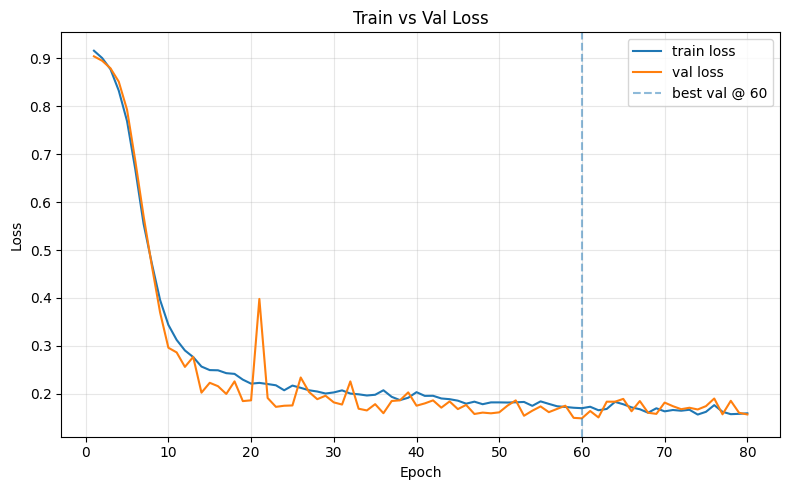

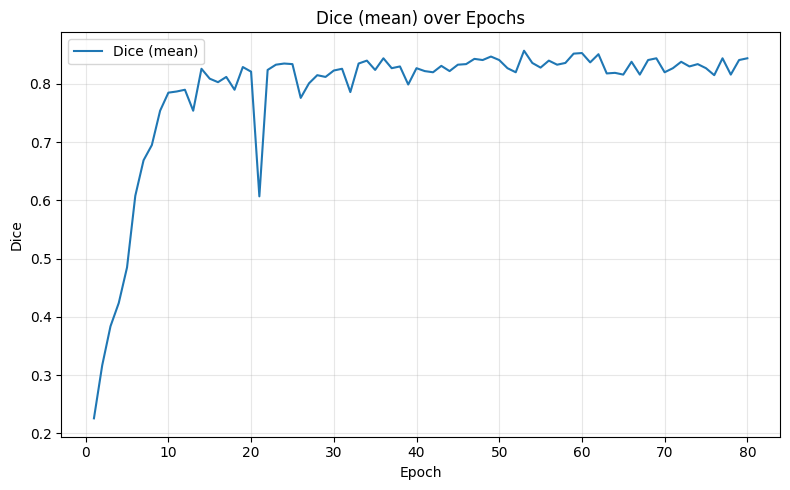

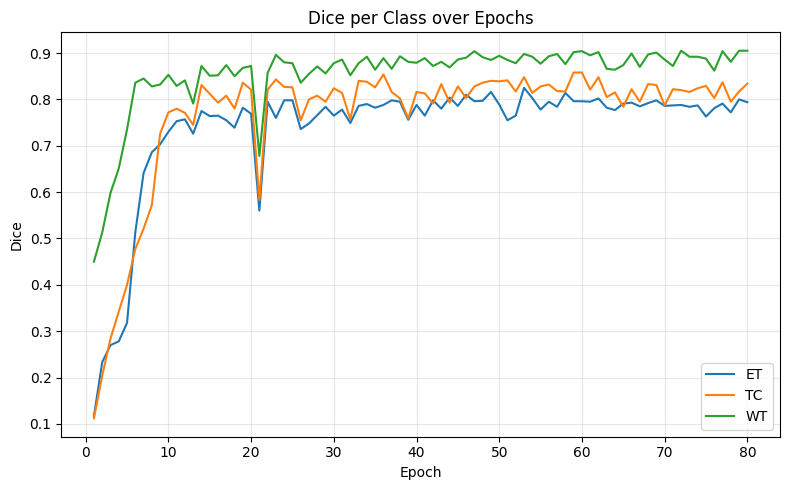

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ganti path sesuai lokasi file kamu
df = pd.read_csv("ReportHasil/Unet_warmupFreeze.csv").sort_values("epoch")

best_idx = df["val_loss"].idxmin()
best_epoch = int(df.loc[best_idx, "epoch"])

# Loss
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="train loss")
plt.plot(df["epoch"], df["val_loss"], label="val loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.5, label=f"best val @ {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Val Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice (mean)
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_mean"], label="Dice (mean)")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice (mean) over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice per kelas
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_et"], label="ET")
plt.plot(df["epoch"], df["dice_tc"], label="TC")
plt.plot(df["epoch"], df["dice_wt"], label="WT")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice per Class over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


# Unet No Regulazation

In [1]:
import os, math, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, EnsureTyped, Compose, SelectItemsd,
    NormalizeIntensityd, CropForegroundd, RandSpatialCropd,
    RandScaleIntensityd, RandShiftIntensityd, RandFlipd, ConcatItemsd, MapTransform
)
from monai.inferers import sliding_window_inference

def log(*a): print(*a, flush=True)

PROJECT_ROOT = Path().resolve()                    # selevel notebook
DATA_ROOT    = PROJECT_ROOT / "data"
# --- KONFIG ---
MAIN_DIR   = DATA_ROOT  # ganti path sesuai datasetmu
BATCH_SIZE = 1                                  # aman di T4 dengan patch 128^3
NUM_WORKERS= 2
ROI = (128, 128, 128)

/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_ROOT    = PROJECT_ROOT / "data"   # kamu bilang sekarang langsung "data"

def looks_like_patient_dir(p: Path) -> bool:
    if not p.is_dir(): return False
    need = ["flair","t1","t1ce","t2","seg"]
    found = 0
    for suf in need:
        if list(p.glob(f"*_{suf}.nii*")):
            found += 1
    return found == len(need)

def auto_find_main_dir(data_root: Path) -> str:
    # 1) data_root → apakah langsung berisi folder pasien?
    subs = [x for x in data_root.iterdir() if x.is_dir()]
    if any(looks_like_patient_dir(x) for x in subs):
        return str(data_root)
    # 2) satu tingkat di bawah
    for sub in subs:
        subs2 = [x for x in sub.iterdir() if x.is_dir()]
        if any(looks_like_patient_dir(x) for x in subs2):
            return str(sub)
    # 3) fallback: cari lebih dalam
    for sub in data_root.rglob("*"):
        if sub.is_dir():
            subs3 = [x for x in sub.iterdir() if x.is_dir()]
            if any(looks_like_patient_dir(x) for x in subs3):
                return str(sub)
    raise RuntimeError(f"Tidak menemukan folder pasien di bawah: {data_root}")

MAIN_DIR = auto_find_main_dir(DATA_ROOT)
print("MAIN_DIR =", MAIN_DIR)

# intip 1 folder pasien & isinya
sample_pat = next((d for d in Path(MAIN_DIR).iterdir() if d.is_dir()), None)
if sample_pat:
    print("Contoh folder pasien:", sample_pat.name)
    print("Contoh file:",
          [p.name for p in sample_pat.glob("*.nii*")])


MAIN_DIR = /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Contoh folder pasien: BraTS20_Training_115
Contoh file: ['BraTS20_Training_115_t1.nii', 'BraTS20_Training_115_seg.nii', 'BraTS20_Training_115_t2.nii', 'BraTS20_Training_115_flair.nii', 'BraTS20_Training_115_t1ce.nii']


In [3]:
def get_data_paths(data_dir):
    def find_file(folder, pid, suffix):
        for ext in (".nii.gz", ".nii"):
            p = os.path.join(folder, f"{pid}_{suffix}{ext}")
            if os.path.exists(p): return p
        return None

    data_paths = []
    print(f"Scanning dataset dir: {data_dir}")
    for pid in sorted(os.listdir(data_dir)):
        pdir = os.path.join(data_dir, pid)
        if not os.path.isdir(pdir): continue
        flair = find_file(pdir, pid, "flair")
        t1    = find_file(pdir, pid, "t1")
        t1gd  = find_file(pdir, pid, "t1ce")
        t2    = find_file(pdir, pid, "t2")
        seg   = find_file(pdir, pid, "seg")
        if all([flair, t1, t1gd, t2, seg]):
            data_paths.append({"flair":flair, "t1":t1, "t1gd":t1gd, "t2":t2, "label":seg, "pid":pid})
    print(f"Found {len(data_paths)} samples.")
    return data_paths

all_paths = get_data_paths(MAIN_DIR)
if not all_paths:
    raise RuntimeError("No data found. Check MAIN_DIR & filenames.")


Scanning dataset dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Found 368 samples.


In [4]:
class BraTSLabelToETTCWT(MapTransform):
    """
    Input d["label"] shape [1,D,H,W] atau [D,H,W] berisi {0,1,2,4}.
    Output d["label_ettcwt"] shape [3,D,H,W]: [ET, TC, WT] sebagai mask biner.
    """
    def __init__(self, keys=("label",), out_key="label_ettcwt"):
        super().__init__(keys); self.out_key = out_key

    def __call__(self, data):
        d = dict(data)
        lab = d[self.keys[0]]
        lab = torch.as_tensor(lab)
        if lab.ndim == 4 and lab.shape[0] == 1: lab = lab[0]  # [D,H,W]
        et = (lab == 4).float()
        tc = ((lab == 1) | (lab == 4)).float()
        wt = ((lab == 1) | (lab == 2) | (lab == 4)).float()
        d[self.out_key] = torch.stack([et, tc, wt], dim=0)  # [3,D,H,W]
        return d

In [5]:
P_RESCALE = 0.20
P_SHIFT   = 0.20
P_FLIP    = 0.50

train_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=True, random_size=False),
    # label → 3C multi-label
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
    # augmentasi B
    RandScaleIntensityd(keys="image", factors=0.1, prob=P_RESCALE),  # ×U[0.9,1.1]
    RandShiftIntensityd(keys="image", offsets=0.1, prob=P_SHIFT),    # +U[-0.1,0.1]
    RandFlipd(keys=["image","label_ettcwt"], prob=P_FLIP, spatial_axis=[0,1,2]),
])

val_transforms = Compose([
    LoadImaged(keys=["flair","t1","t1gd","t2","label"]),
    EnsureChannelFirstd(keys=["flair","t1","t1gd","t2","label"]),
    ConcatItemsd(keys=["flair","t1","t1gd","t2"], name="image", dim=0),
    EnsureTyped(keys=["image","label"], track_meta=False),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image","label"], source_key="image"),
    RandSpatialCropd(keys=["image","label"], roi_size=ROI, random_center=False, random_size=False),
    BraTSLabelToETTCWT(keys=("label",), out_key="label_ettcwt"),
    SelectItemsd(keys=["image","label_ettcwt","pid"]),
])


/mnt/extended-home/pityudhistira28/anaconda3/envs/adit-intern/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [6]:
class BraTSDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = list(items); self.tx = transform
        if not self.items: raise ValueError("Empty dataset")
    def __len__(self): return len(self.items)
    def __getitem__(self, i): 
        s = self.items[i]
        return self.tx(s) if self.tx else s

rng = np.random.RandomState(42)
perm = rng.permutation(len(all_paths))
all_paths = [all_paths[i] for i in perm]
cut = int(0.8*len(all_paths))
train_ds = BraTSDataset(all_paths[:cut], transform=train_transforms)
val_ds   = BraTSDataset(all_paths[cut:],  transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

log(f"Loaders OK | train={len(train_ds)} val={len(val_ds)} bs={BATCH_SIZE}")

Loaders OK | train=294 val=74 bs=1


In [7]:
# ================================================
# UNet 3D + MedicalNet ResNet18 encoder (T4-friendly)
# Skip-connections sederhana ala pytorch-3dunet:
#   upsample -> concat(skip) -> TwoConv
# ================================================
import torch.nn as nn
import torch.nn.functional as F
from monai.networks.layers.factories import Conv
from monai.networks.nets.basic_unet import TwoConv, UpCat
import monai.networks.nets.resnet as monai_resnet


def prepare_medicalnet_state_for_monai(sd_in, in_channels=4):
    sd_raw = sd_in.get("state_dict", sd_in)
    sd = dict(sd_raw)
    remap = {}

    for k, v in sd.items():
        kk = k[len("module."):] if k.startswith("module.") else k

        # drop classifier
        if kk.startswith("fc."):
            continue

        # strip inner ".conv" (varian yang simpan conv submodule)
        kk = kk.replace(".conv1.conv.", ".conv1.")
        kk = kk.replace(".conv2.conv.", ".conv2.")
        kk = kk.replace(".conv3.conv.", ".conv3.")  # aman utk R50 juga

        # map style 'downsample.conv/bn' → 'downsample.0/1'
        kk = kk.replace(".downsample.conv.", ".downsample.0.")
        kk = kk.replace(".downsample.bn.",  ".downsample.1.")

        # map style 'shortcut' → 'downsample'
        kk = kk.replace(".shortcut.0.", ".downsample.0.")
        kk = kk.replace(".shortcut.1.", ".downsample.1.")

        # sebagian ckpt pakai 'downsample.weight' (tanpa .0) → asumsi conv
        if ".downsample.weight" in kk and ".downsample.0.weight" not in kk:
            kk = kk.replace(".downsample.weight", ".downsample.0.weight")
        if ".downsample.bias" in kk and ".downsample.0.bias" not in kk:
            kk = kk.replace(".downsample.bias", ".downsample.0.bias")

        remap[kk] = v

    # adapt conv1 Cin=1 → multi-modal (mis. 4)
    for conv1_key in ["conv1.weight", "conv1.conv.weight"]:
        if conv1_key in remap:
            w = remap[conv1_key]
            if w.ndim == 5 and w.shape[1] == 1 and in_channels > 1:
                w = w.mean(1, keepdim=True).repeat(1, in_channels, 1, 1, 1) / float(in_channels)
                remap[conv1_key] = w
                break

    return remap


@torch.no_grad()
def load_medicalnet_into_monai_resnet(backbone, pth_path, in_channels=4, verbose=True):
    raw = torch.load(pth_path, map_location="cpu")
    sd  = prepare_medicalnet_state_for_monai(raw, in_channels=in_channels)
    info = backbone.load_state_dict(sd, strict=False)
    try:
        missing, unexpected = info.missing_keys, info.unexpected_keys
    except AttributeError:
        missing, unexpected = info
    if verbose:
        monai_keys = backbone.state_dict()
        matched = sum(int(k in monai_keys and monai_keys[k].shape == sd[k].shape) for k in sd.keys())
        print(f"[MedicalNet→MONAI] matched={matched}  missing={len(missing)}  unexpected={len(unexpected)}")
    return info


class MedicalNetResNet18Encoder(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()
        self.backbone = monai_resnet.resnet18(
            spatial_dims=3, n_input_channels=in_channels, pretrained=False, progress=False
        )
        self.layer1 = self.backbone.layer1
        self.layer2 = self.backbone.layer2
        self.layer3 = self.backbone.layer3
        self.layer4 = self.backbone.layer4

    @torch.no_grad()
    def load_medicalnet_pretrain(self, pth_path, in_channels=4):
        load_medicalnet_into_monai_resnet(
            backbone=self.backbone, pth_path=pth_path, in_channels=in_channels, verbose=True
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = F.relu(x, inplace=True)
        s0 = x                 # <<< /2 tap (SEBELUM maxpool)
        x  = self.backbone.maxpool(x)
        s1 = self.layer1(x)    # /4
        s2 = self.layer2(s1)   # /8
        s3 = self.layer3(s2)   # /16
        # s4 = self.layer4(s3) # /32 (TIDAK dipakai di UNet++ 5-level)
        return s0, s1, s2, s3


class UNet3D_Decoder(nn.Module):
    """
    UNet 3D decoder dengan 4 tingkat skip dari encoder:
      - Input (/1) → conv_0_0 untuk memberi skip paling dangkal
      - Encoder taps: s0(~ /2), s1(~ /4), s2(~ /8), s3(~ /16)
    Alur:
      bottleneck(s3) → UpCat dengan s2 → UpCat dengan s1 → UpCat dengan s0 → UpCat dengan x_0_0 → head
    """
    def __init__(
        self,
        spatial_dims=3,
        in_channels=4,
        out_channels=3,
        # fitur kecil agar muat di T4 (sesuaikan bila VRAM longgar)
        features=(16, 32, 64, 128, 128),  # F0, F1, F2, F3, F4(bottleneck)
        act=("LeakyReLU", {"negative_slope": 0.1, "inplace": True}),
        norm=("instance", {"affine": True}),
        dropout=0.0,
        upsample="nontrainable",          # hemat VRAM
        enc_channels=(64, 128, 256, 512), # taps ResNet18
        deep_supervision=False,           # default UNet: single head
    ):
        super().__init__()
        self.deep_supervision = deep_supervision
        F0, F1, F2, F3, F4 = features

        # Adaptasi channel skip dari encoder → dim UNet
        Conv1x1 = lambda a, b: Conv["conv", spatial_dims](a, b, kernel_size=1, bias=False)
        self.adapt_s0 = Conv1x1(enc_channels[0], F1)  # /2
        self.adapt_s1 = Conv1x1(enc_channels[1], F2)  # /4
        self.adapt_s2 = Conv1x1(enc_channels[2], F3)  # /8
        self.adapt_s3 = Conv1x1(enc_channels[3], F4)  # /16 (bottleneck in)

        # Blok paling dangkal di resolusi /1 (untuk skip terakhir)
        self.conv_0_0 = TwoConv(spatial_dims, in_channels, F0, act, norm, bias=True, dropout=dropout)

        # Bottleneck pada /16
        self.bottleneck = TwoConv(spatial_dims, F4, F4, act, norm, bias=True, dropout=dropout)

        # Up-sampling ladder (trilinear → concat → TwoConv)
        # /16 → /8
        self.up_3 = UpCat(spatial_dims, F4, F3, F3, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /8 → /4
        self.up_2 = UpCat(spatial_dims, F3, F2, F2, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /4 → /2
        self.up_1 = UpCat(spatial_dims, F2, F1, F1, act, norm, bias=True, dropout=dropout,
                           upsample=upsample)
        # /2 → /1 (skip dengan x_0_0)
        # NOTE: halves=False agar channels skip + up sama persis
        self.up_0 = UpCat(spatial_dims, F1, F0, F0, act, norm, bias=True, dropout=dropout,
                           upsample=upsample, halves=False)

        # Head
        self.head = Conv["conv", spatial_dims](F0, out_channels, kernel_size=1)

        # (opsional) heads untuk deep supervision jika ingin dihidupkan
        if self.deep_supervision:
            self.ds2 = Conv["conv", spatial_dims](F1, out_channels, kernel_size=1)  # /2
            self.ds3 = Conv["conv", spatial_dims](F2, out_channels, kernel_size=1)  # /4
            self.ds4 = Conv["conv", spatial_dims](F3, out_channels, kernel_size=1)  # /8

    def forward(self, x, feats):
        """
        x: input citra [B, C, D, H, W] (resolusi /1)
        feats: (s0, s1, s2, s3) dari encoder ResNet18 (kira-kira /2, /4, /8, /16)
        """
        s0, s1, s2, s3 = feats

        # Normalisasi spasial → tepat /2,/4,/8,/16 dari ukuran input setelah conv_0_0
        x_0_0 = self.conv_0_0(x)   # /1
        D, H, W = x_0_0.shape[2:]
        size_1  = (max(1, D // 2),  max(1, H // 2),  max(1, W // 2))   # /2
        size_2  = (max(1, D // 4),  max(1, H // 4),  max(1, W // 4))   # /4
        size_3  = (max(1, D // 8),  max(1, H // 8),  max(1, W // 8))   # /8
        size_4  = (max(1, D // 16), max(1, H // 16), max(1, W // 16))  # /16

        # Adapt channel lalu *force* ke ukuran yang konsisten
        s0 = F.interpolate(self.adapt_s0(s0), size=size_1, mode="trilinear", align_corners=False)
        s1 = F.interpolate(self.adapt_s1(s1), size=size_2, mode="trilinear", align_corners=False)
        s2 = F.interpolate(self.adapt_s2(s2), size=size_3, mode="trilinear", align_corners=False)
        s3 = F.interpolate(self.adapt_s3(s3), size=size_4, mode="trilinear", align_corners=False)

        # Bottleneck (/16)
        x_3 = self.bottleneck(s3)

        # Naik tangga UNet
        x_2 = self.up_3(x_3, s2)              # /8
        x_1 = self.up_2(x_2, s1)              # /4
        x_0_5 = self.up_1(x_1, s0)            # /2
        x_out = self.up_0(x_0_5, x_0_0)       # /1

        y = self.head(x_out)

        if not self.deep_supervision:
            return y

        # Deep supervision (opsional): kembalikan beberapa prediksi multi-scale
        y_ds2 = self.ds2(x_0_5)  # /2
        y_ds3 = self.ds3(x_1)    # /4
        y_ds4 = self.ds4(x_2)    # /8
        # urutan: finest → coarser (selaras dgn pola Anda)
        return [y, y_ds2, y_ds3, y_ds4]


class UNet3D_MedicalNet(nn.Module):
    """
    Wrapper: ResNet18 3D (MedicalNet) sebagai encoder + UNet decoder klasik.
    Output channels default=3 (ET/TC/WT) → gunakan sigmoid di loss (multi-label).
    """
    def __init__(
        self,
        in_channels=4,
        out_channels=3,
        features=(16, 32, 64, 128, 128),
        enc_channels=(64, 128, 256, 512),
        deep_supervision=False,
    ):
        super().__init__()
        self.encoder = MedicalNetResNet18Encoder(in_channels=in_channels)
        self.decoder = UNet3D_Decoder(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            features=features,
            enc_channels=enc_channels,
            upsample="nontrainable",
            deep_supervision=deep_supervision,
        )

    def load_medicalnet(self, pth_path):
        """
        pth_path: path ke weight MedicalNet (mis: resnet_18_23dataset.pth)
        """
        self.encoder.load_medicalnet_pretrain(
            pth_path=pth_path,
            in_channels=self.encoder.backbone.conv1.in_channels,
        )

    def forward(self, x):
        feats = self.encoder(x)      # (s0, s1, s2, s3)
        return self.decoder(x, feats)


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet3D_MedicalNet(
        in_channels=4,            # FLAIR,T1,T1ce,T2
        out_channels=3,           # ET/TC/WT (multi-label → sigmoid di loss)
        features=(16,32,64,128,128),
        enc_channels=(64, 64, 128, 256),
        deep_supervision=True,  # kecilkan jika VRAM mepet: (32,64,128,256,256,32)
    ).to("cuda")

# path MedicalNet (.pth) dari "Models" Kaggle (pakai pencari kalau perlu)
PROJECT_ROOT = Path().resolve()  # folder tempat notebook berada
MEDNET_PTH   = PROJECT_ROOT / "Pretrained" / "resnet_18_23dataset.pth"
model.load_medicalnet(MEDNET_PTH)

[MedicalNet→MONAI] matched=102  missing=20  unexpected=0


/tmp/ipykernel_1647668/622822728.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pth_path, map_location="cpu")


In [9]:
# === setelah model di-instansiasi & (opsional) load bobot ===
# model = UNetPP3D_MedicalNet(...).cuda()
# model.load_medicalnet(MEDNET_PTH)

import torch
import torch.nn as nn

def init_identity_downsample(block_down, in_ch, out_ch, stride=2):
    """
    block_down: nn.Sequential(conv1x1, bn)
    Set conv 1x1 jadi 'copy channel' (diagonal) dgn stride sesuai, BN -> γ=1, β=0, running stats reset.
    """
    conv = block_down[0]; bn = block_down[1]
    assert isinstance(conv, nn.Conv3d) and isinstance(bn, (nn.BatchNorm3d, nn.SyncBatchNorm)), \
        "Ekspektasi downsample = [Conv3d, BatchNorm3d]"

    # nolkan dulu, lalu isi diagonal agar menyalin channel sebanyak min(in_ch, out_ch)
    nn.init.zeros_(conv.weight)
    if conv.bias is not None:
        nn.init.zeros_(conv.bias)
    c = min(in_ch, out_ch)
    with torch.no_grad():
        for i in range(c):
            conv.weight[i, i, 0, 0, 0] = 1.0

    # BN ke identitas
    nn.init.ones_(bn.weight)
    nn.init.zeros_(bn.bias)
    bn.running_mean.zero_()
    bn.running_var.fill_(1)

def reinit_missing_downsamples_resnet18(backbone):
    # R18 taps: layer2.0, layer3.0, layer4.0 masing-masing punya downsample (stride=2)
    init_identity_downsample(backbone.layer2[0].downsample, in_ch=64,  out_ch=128, stride=2)
    init_identity_downsample(backbone.layer3[0].downsample, in_ch=128, out_ch=256, stride=2)
    init_identity_downsample(backbone.layer4[0].downsample, in_ch=256, out_ch=512, stride=2)

# PANGGIL DI SINI (setelah load pretrained)
reinit_missing_downsamples_resnet18(model.encoder.backbone)

# (opsional) cepat cek satu nilai diagonal untuk memastikan terisi:
print("diag l2:", model.encoder.backbone.layer2[0].downsample[0].weight[0,0,0,0,0].item())


diag l2: 1.0


In [10]:
for m in model.encoder.backbone.modules():
    if isinstance(m, (nn.BatchNorm3d, nn.SyncBatchNorm)):
        m.eval()

In [11]:
def dice_per_region(pred_bin, lab_bin, eps=1e-6):
    # pred_bin & lab_bin: [B,3,D,H,W] biner
    dims = (0,2,3,4)
    inter = (pred_bin * lab_bin).sum(dim=dims)                  # [3]
    den   = pred_bin.sum(dim=dims) + lab_bin.sum(dim=dims)      # [3]
    return (2*inter + eps) / (den + eps)  

In [12]:
import torch
import torch.nn.functional as F

def _resize_to_target(o: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    # Samakan spatial size prediksi ke label (D,H,W) jika berbeda
    if o.shape[2:] != target.shape[2:]:
        o = F.interpolate(o, size=target.shape[2:], mode="trilinear", align_corners=False)
    return o

def multilabel_dice_loss(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    logits = _resize_to_target(logits, target)    # <<< kunci Opsi A
    probs = torch.sigmoid(logits)
    dims = (0, 2, 3, 4)                           # batch + spatial, per-channel dice
    inter = (probs * target).sum(dims)
    den   = probs.sum(dims) + target.sum(dims)
    dice  = (2 * inter + eps) / (den + eps)
    return 1.0 - dice.mean()

def ds_loss(outputs, target, weights=None):
    # Mendukung: single output atau list/tuple (deep supervision)
    if isinstance(outputs, (list, tuple)):
        if weights is None:
            # Konsisten untuk 4 head (bisa dipangkas sesuai jumlah head aktual)
            weights = [1.0, 0.5, 0.25, 0.125][:len(outputs)]
        losses = [w * multilabel_dice_loss(o, target) for o, w in zip(outputs, weights)]
        return sum(losses) / sum(weights)
    return multilabel_dice_loss(outputs, target)


In [13]:
def split_wd(named_params):
    decay, no_decay = [], []
    for n,p in named_params:
        if not p.requires_grad: continue
        if p.ndim == 1 or n.endswith(".bias"):
            no_decay.append(p)      # norm & bias
        else:
            decay.append(p)
    return [{"params":decay, "weight_decay":1e-2},
            {"params":no_decay, "weight_decay":0.0}]

enc_groups = split_wd(model.encoder.named_parameters())
dec_groups = split_wd(model.decoder.named_parameters())

optimizer = torch.optim.AdamW(
    [
        {**enc_groups[0], "lr": 1e-4},  # encoder w/ decay
        {**enc_groups[1], "lr": 1e-4},  # encoder no-decay
        {**dec_groups[0], "lr": 2e-4},  # decoder w/ decay
        {**dec_groups[1], "lr": 2e-4},  # decoder no-decay
    ]
)
scheduler = None
MAX_EPOCHS = 200

In [14]:
from tqdm import tqdm
from torch.amp import autocast
import time

# --- helper agar aman jika output berupa list/tuple (ambil head utama) ---
def _ensure_tensor(o):
    return o[0] if isinstance(o, (list, tuple)) else o

scaler = GradScaler(enabled=True)
device = "cuda"
early_patience = 20
best_val = float("inf"); bad = 0
best_state = None

# stabilkan BN encoder (batch kecil)
for m in model.encoder.modules():
    if isinstance(m, (torch.nn.BatchNorm3d, torch.nn.SyncBatchNorm)):
        m.eval()

for epoch in range(MAX_EPOCHS):
    model.train()
    tr = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [train]", leave=False)
    for batch in pbar:
        img = batch["image"].to(device, non_blocking=True)                 # [B,4,D,H,W]
        lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda"):
            out = model(img)                   # bisa tensor atau list (DS)
            loss = ds_loss(out, lab)           # ds_loss kita sudah handle list/tensor
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()

        tr += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    tr /= max(1, len(train_loader))

    # ---- validation (sliding window) ----
    model.eval()
    va = 0.0
    dice_sums = torch.zeros(3, device=device)  # akumulasi Dice ET/TC/WT
    n_batches  = 0
    
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [val]", leave=False)
    with torch.no_grad():
        for batch in pbar_val:
            img = batch["image"].to(device, non_blocking=True)
            lab = batch["label_ettcwt"].to(device, non_blocking=True).float()  # [B,3,D,H,W]
    
            with autocast("cuda"):
                logits = sliding_window_inference(
                    img, roi_size=ROI, sw_batch_size=1,
                    predictor=model, overlap=0.5, mode="gaussian"
                )
                logits = _ensure_tensor(logits)          # <-- penting: pastikan tensor utama
                loss = multilabel_dice_loss(logits, lab) # aman (full-res/no-op resize untuk UNet++)
            va += loss.item(); n_batches += 1
    
            # --- METRICS: Dice per region ---
            probs = torch.sigmoid(logits)
            pred_bin = (probs > 0.5).float()
            lab_bin  = (lab   > 0.5).float()
            dice_cls = dice_per_region(pred_bin, lab_bin)  # [ET,TC,WT]
            dice_sums += dice_cls
    
            # tampilkan di progress bar (mean sementara)
            dice_tmp = (dice_sums / n_batches).detach().cpu().tolist()
            pbar_val.set_postfix(val_loss=f"{loss.item():.4f}",
                                 dice=f"ET:{dice_tmp[0]:.3f}|TC:{dice_tmp[1]:.3f}|WT:{dice_tmp[2]:.3f}")
    
    va /= max(1, n_batches)
    
    # ringkas Dice epoch
    dice_mean_per_cls = (dice_sums / max(1, n_batches)).detach().cpu().tolist()  # [ET,TC,WT]
    dice_mean = float(sum(dice_mean_per_cls)/3.0)
    names = ["ET","TC","WT"]
    dice_str = " | ".join(f"{n}:{v:.3f}" for n,v in zip(names, dice_mean_per_cls))
    
    log(f"[{epoch+1:03d}/{MAX_EPOCHS}] train={tr:.4f}  val={va:.4f}  Dice(mean)={dice_mean:.3f} ({dice_str})")

    if scheduler is not None:
        scheduler.step()

    if va < best_val - 1e-6:
        best_val = va; bad = 0
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    else:
        bad += 1
        if bad >= early_patience:
            log(f"Early stop at {epoch+1}, best val={best_val:.4f}")
            break

CKPT_DIR = Path().resolve() / "checkpoints_unet_raw"   # folder sejajar notebook
CKPT_DIR.mkdir(parents=True, exist_ok=True)

stamp = time.strftime("%Y%m%d-%H%M%S")
best_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_best_{stamp}.pt"
last_path = CKPT_DIR / f"unetpp_medicalnet_multilabel_last_{stamp}.pt"

# simpan BEST (berdasarkan val loss)
if best_state is not None:
    model.load_state_dict(best_state, strict=True)
    torch.save(model.state_dict(), best_path)
    log("saved BEST:", str(best_path))

# simpan LAST (state setelah epoch terakhir) — opsional tapi berguna untuk resume cepat
torch.save(model.state_dict(), last_path)
log("saved LAST:", str(last_path))

# (opsional) simpan checkpoint lengkap utk resume (model+optim+sched+scaler)
full_ckpt_path = CKPT_DIR / f"checkpoint_full_{stamp}.pt"
torch.save({
    "epoch": epoch + 1,
    "best_val": best_val,
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scaler": scaler.state_dict(),
}, full_ckpt_path)
log("saved FULL checkpoint:", str(full_ckpt_path))



/tmp/ipykernel_1647668/408942977.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)
                                                                                                                    

[001/200] train=0.8911  val=0.8873  Dice(mean)=0.296 (ET:0.047 | TC:0.325 | WT:0.517)


[002/200] train=0.8274  val=0.8481  Dice(mean)=0.420 (ET:0.057 | TC:0.455 | WT:0.747)


[003/200] train=0.7411  val=0.7847  Dice(mean)=0.509 (ET:0.272 | TC:0.461 | WT:0.794)


[004/200] train=0.6455  val=0.6874  Dice(mean)=0.563 (ET:0.389 | TC:0.486 | WT:0.814)


...

[083/200] train=0.1603  val=0.1604  Dice(mean)=0.840 (ET:0.799 | TC:0.819 | WT:0.903)


[084/200] train=0.1560  val=0.1470  Dice(mean)=0.858 (ET:0.819 | TC:0.849 | WT:0.908)


[085/200] train=0.1631  val=0.1921  Dice(mean)=0.813 (ET:0.779 | TC:0.763 | WT:0.898)


[086/200] train=0.1644  val=0.1990  Dice(mean)=0.806 (ET:0.780 | TC:0.786 | WT:0.853)
Early stop at 86, best val=0.1406


saved BEST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet_raw/unetpp_medicalnet_multilabel_best_20251015-041427.pt
saved LAST: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet_raw/unetpp_medicalnet_multilabel_last_20251015-041427.pt
saved FULL checkpoint: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/checkpoints_unet_raw/checkpoint_full_20251015-041427.pt


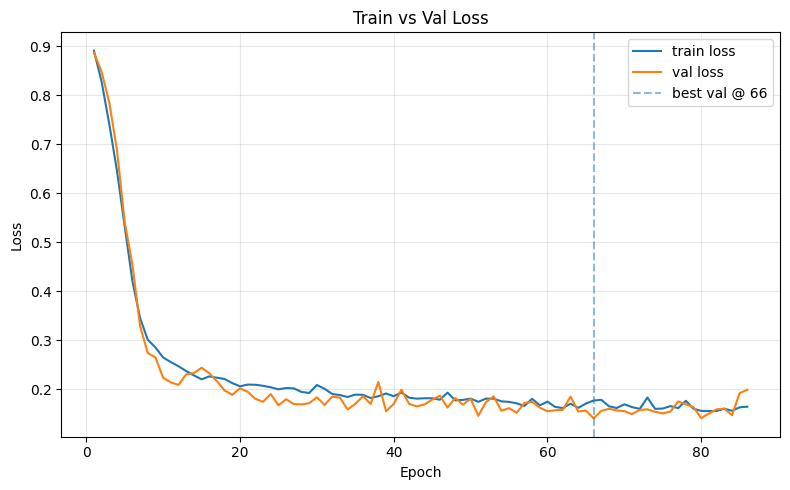

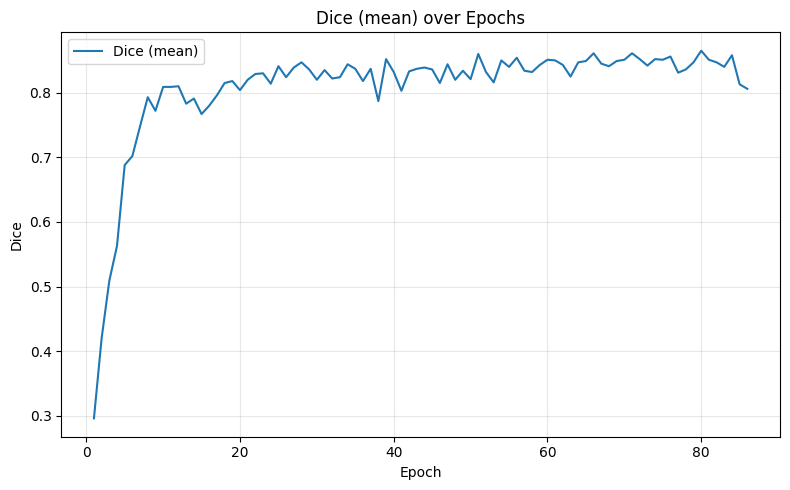

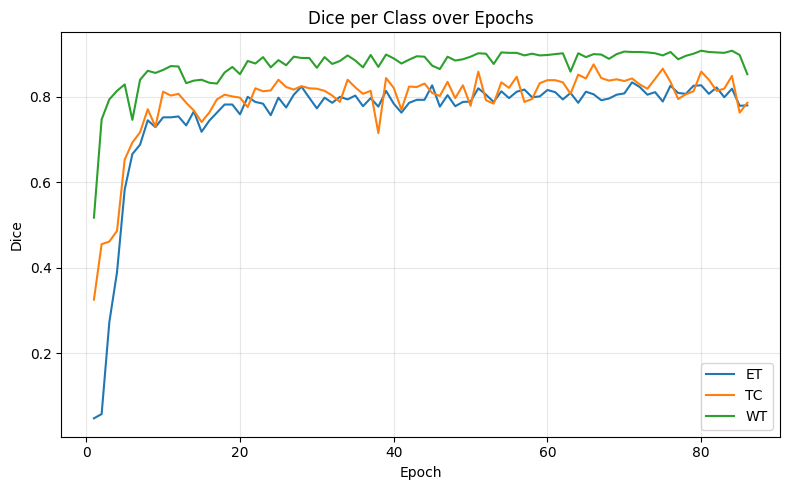

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ganti path sesuai lokasi file kamu
df = pd.read_csv("ReportHasil/Unet_raw.csv").sort_values("epoch")

best_idx = df["val_loss"].idxmin()
best_epoch = int(df.loc[best_idx, "epoch"])

# Loss
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["train_loss"], label="train loss")
plt.plot(df["epoch"], df["val_loss"], label="val loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.5, label=f"best val @ {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train vs Val Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice (mean)
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_mean"], label="Dice (mean)")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice (mean) over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Dice per kelas
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["dice_et"], label="ET")
plt.plot(df["epoch"], df["dice_tc"], label="TC")
plt.plot(df["epoch"], df["dice_wt"], label="WT")
plt.xlabel("Epoch"); plt.ylabel("Dice"); plt.title("Dice per Class over Epochs")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


# Visulisasi

In [6]:
import os, math, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from monai.transforms import (
    LoadImaged, EnsureChannelFirstd, EnsureTyped, Compose, SelectItemsd,
    NormalizeIntensityd, CropForegroundd, RandSpatialCropd,
    RandScaleIntensityd, RandShiftIntensityd, RandFlipd, ConcatItemsd, MapTransform
)
from monai.inferers import sliding_window_inference

def log(*a): print(*a, flush=True)

PROJECT_ROOT = Path().resolve()                    # selevel notebook
DATA_ROOT    = PROJECT_ROOT / "data"
# --- KONFIG ---
MAIN_DIR   = DATA_ROOT  # ganti path sesuai datasetmu
BATCH_SIZE = 1                                  # aman di T4 dengan patch 128^3
NUM_WORKERS= 2
ROI = (128, 128, 128)

In [7]:
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_ROOT    = PROJECT_ROOT / "data"   # kamu bilang sekarang langsung "data"

def looks_like_patient_dir(p: Path) -> bool:
    if not p.is_dir(): return False
    need = ["flair","t1","t1ce","t2","seg"]
    found = 0
    for suf in need:
        if list(p.glob(f"*_{suf}.nii*")):
            found += 1
    return found == len(need)

def auto_find_main_dir(data_root: Path) -> str:
    # 1) data_root → apakah langsung berisi folder pasien?
    subs = [x for x in data_root.iterdir() if x.is_dir()]
    if any(looks_like_patient_dir(x) for x in subs):
        return str(data_root)
    # 2) satu tingkat di bawah
    for sub in subs:
        subs2 = [x for x in sub.iterdir() if x.is_dir()]
        if any(looks_like_patient_dir(x) for x in subs2):
            return str(sub)
    # 3) fallback: cari lebih dalam
    for sub in data_root.rglob("*"):
        if sub.is_dir():
            subs3 = [x for x in sub.iterdir() if x.is_dir()]
            if any(looks_like_patient_dir(x) for x in subs3):
                return str(sub)
    raise RuntimeError(f"Tidak menemukan folder pasien di bawah: {data_root}")

MAIN_DIR = auto_find_main_dir(DATA_ROOT)
print("MAIN_DIR =", MAIN_DIR)

# intip 1 folder pasien & isinya
sample_pat = next((d for d in Path(MAIN_DIR).iterdir() if d.is_dir()), None)
if sample_pat:
    print("Contoh folder pasien:", sample_pat.name)
    print("Contoh file:",
          [p.name for p in sample_pat.glob("*.nii*")])


MAIN_DIR = /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Contoh folder pasien: BraTS20_Training_115
Contoh file: ['BraTS20_Training_115_t1.nii', 'BraTS20_Training_115_seg.nii', 'BraTS20_Training_115_t2.nii', 'BraTS20_Training_115_flair.nii', 'BraTS20_Training_115_t1ce.nii']


In [8]:
def get_data_paths(data_dir):
    def find_file(folder, pid, suffix):
        for ext in (".nii.gz", ".nii"):
            p = os.path.join(folder, f"{pid}_{suffix}{ext}")
            if os.path.exists(p): return p
        return None

    data_paths = []
    print(f"Scanning dataset dir: {data_dir}")
    for pid in sorted(os.listdir(data_dir)):
        pdir = os.path.join(data_dir, pid)
        if not os.path.isdir(pdir): continue
        flair = find_file(pdir, pid, "flair")
        t1    = find_file(pdir, pid, "t1")
        t1gd  = find_file(pdir, pid, "t1ce")
        t2    = find_file(pdir, pid, "t2")
        seg   = find_file(pdir, pid, "seg")
        if all([flair, t1, t1gd, t2, seg]):
            data_paths.append({"flair":flair, "t1":t1, "t1gd":t1gd, "t2":t2, "label":seg, "pid":pid})
    print(f"Found {len(data_paths)} samples.")
    return data_paths

all_paths = get_data_paths(MAIN_DIR)
if not all_paths:
    raise RuntimeError("No data found. Check MAIN_DIR & filenames.")


Scanning dataset dir: /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Found 368 samples.


In [9]:
# ========= NIfTI visualizer (BraTS-style) =========
# Fitur:
# - Load 4 modalitas (flair, t1, t1gd/t1ce, t2) + label
# - Normalisasi per modalitas (percentile clip → 0..1)
# - Pilih slice axial (otomatis di tengah lesi kalau ada label; fallback: tengah volume)
# - Overlay label (opsi: any mask / ET / TC / WT) dgn warna tematik
# - Viewer interaktif (slider) untuk scroll slice
# ==================================================

import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ---- Helpers ----
def load_nii(path, canonical=True, dtype=np.float32):
    img = nib.load(path)
    if canonical:
        img = nib.as_closest_canonical(img)
    data = img.get_fdata().astype(dtype)
    return data, img.affine

def pct_normalize(vol, pmin=0.5, pmax=99.5, eps=1e-8):
    lo, hi = np.percentile(vol[np.isfinite(vol)], [pmin, pmax])
    vol = np.clip(vol, lo, hi)
    vol = (vol - lo) / max(hi - lo, eps)
    vol = np.nan_to_num(vol, nan=0.0, posinf=1.0, neginf=0.0)
    return vol

def pick_axial_slice(label_vol):
    """Ambil slice axial representatif:
       - kalau ada label >0 → pakai median index dari bbox lesi
       - kalau tidak ada → pakai tengah volume
    """
    D, H, W = label_vol.shape
    nz = np.argwhere(label_vol > 0)
    if nz.size == 0:
        return D // 2
    zmin, ymin, xmin = nz.min(0)
    zmax, ymax, xmax = nz.max(0)
    return int((zmin + zmax) // 2)

def make_composite_masks(label_vol):
    """
    Mapping umum BraTS:
      1: necrotic/non-enhancing tumor core
      2: edema
      4: enhancing tumor
    Komposit:
      ET = (label == 4)
      TC = (label == 1) | (label == 4)
      WT = (label > 0)
    """
    et = (label_vol == 4)
    tc = (label_vol == 1) | (label_vol == 4)
    wt = (label_vol > 0)
    return {"ET": et, "TC": tc, "WT": wt, "ANY": wt}

def overlay_mask(ax, base_img, mask, alpha=0.35, colors=None):
    """
    colors: dict kelas→RGBA 0..1
    Default: warna berbeda untuk ET/TC/WT/ANY
    """
    ax.imshow(base_img, cmap="gray", vmin=0, vmax=1)
    if colors is None:
        colors = {
            "ET": (1.0, 0.2, 0.2, alpha),   # merah
            "TC": (1.0, 0.8, 0.2, alpha),  # kuning
            "WT": (0.2, 0.8, 0.2, alpha),  # hijau
            "ANY": (0.3, 0.6, 1.0, alpha), # biru
        }
    # kalau mask adalah dict (banyak kelas), gambar semuanya
    if isinstance(mask, dict):
        for k, m in mask.items():
            if m.any():
                overlay = np.zeros((*m.shape, 4), dtype=float)
                overlay[m] = colors.get(k, (1, 0, 1, alpha))  # fallback magenta
                ax.imshow(overlay)
    else:
        if mask.any():
            overlay = np.zeros((*mask.shape, 4), dtype=float)
            overlay[mask] = colors.get("ANY", (0.3, 0.6, 1.0, alpha))
            ax.imshow(overlay)

# ---- Visualisasi statis: satu baris 4 modalitas + overlay ----
def show_case_panel(case_paths, which_mask="WT", z_index=None, title=None, figsize=(14, 3.5)):
    """
    case_paths: dict {"flair":..., "t1":..., "t1gd":..., "t2":..., "label":..., "pid":...}
    which_mask: "ANY" | "ET" | "TC" | "WT" | "ALL" (semua ET/TC/WT ditumpuk)
    z_index: paksa index axial tertentu; None → pilih otomatis
    """
    flair, _ = load_nii(case_paths["flair"])
    t1, _    = load_nii(case_paths["t1"])
    t1gd, _  = load_nii(case_paths.get("t1gd") or case_paths.get("t1ce"))
    t2, _    = load_nii(case_paths["t2"])
    label, _ = load_nii(case_paths["label"], dtype=np.int16)

    # Pastikan shape sama
    assert flair.shape == t1.shape == t1gd.shape == t2.shape == label.shape, \
        f"Shape mismatch: {[x.shape for x in [flair,t1,t1gd,t2,label]]}"

    # Normalisasi 0..1 per modalitas
    flair_n = pct_normalize(flair)
    t1_n    = pct_normalize(t1)
    t1gd_n  = pct_normalize(t1gd)
    t2_n    = pct_normalize(t2)

    # Pilih slice
    if z_index is None:
        z_index = pick_axial_slice(label)

    comps = make_composite_masks(label)
    if which_mask == "ALL":
        mask_to_draw = {"WT": comps["WT"], "TC": comps["TC"], "ET": comps["ET"]}
    else:
        mask_to_draw = comps.get(which_mask.upper(), comps["WT"])

    fig, axes = plt.subplots(1, 4, figsize=figsize)
    for ax, img, name in zip(
        axes,
        [flair_n, t1_n, t1gd_n, t2_n],
        ["FLAIR", "T1", "T1CE", "T2"]
    ):
        overlay_mask(ax, img[z_index, :, :], mask_to_draw[z_index, :, :] if isinstance(mask_to_draw, np.ndarray) else {k:v[z_index] for k,v in mask_to_draw.items()})
        ax.set_title(name)
        ax.axis("off")

    if title is None:
        title = f"PID: {case_paths.get('pid','?')}  |  z={z_index}  |  mask={which_mask}"
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


# ---- Viewer interaktif (slider axial) ----
def interactive_viewer(case_paths, which_mask="WT", figsize=(10, 4)):
    flair, _ = load_nii(case_paths["flair"])
    t1, _    = load_nii(case_paths["t1"])
    t1gd, _  = load_nii(case_paths.get("t1gd") or case_paths.get("t1ce"))
    t2, _    = load_nii(case_paths["t2"])
    label, _ = load_nii(case_paths["label"], dtype=np.int16)

    flair_n = pct_normalize(flair)
    t1_n    = pct_normalize(t1)
    t1gd_n  = pct_normalize(t1gd)
    t2_n    = pct_normalize(t2)

    D, H, W = label.shape
    comps = make_composite_masks(label)
    if which_mask == "ALL":
        mask_to_draw = {"WT": comps["WT"], "TC": comps["TC"], "ET": comps["ET"]}
    else:
        mask_to_draw = comps.get(which_mask.upper(), comps["WT"])

    z0 = pick_axial_slice(label)

    fig, axes = plt.subplots(1, 4, figsize=figsize)
    plt.subplots_adjust(bottom=0.18)
    ims = []
    for ax, img, name in zip(
        axes,
        [flair_n, t1_n, t1gd_n, t2_n],
        ["FLAIR", "T1", "T1CE", "T2"]
    ):
        overlay_mask(ax, img[z0, :, :], mask_to_draw[z0, :, :] if isinstance(mask_to_draw, np.ndarray) else {k:v[z0] for k,v in mask_to_draw.items()})
        ax.set_title(name)
        ax.axis("off")

    # Slider
    ax_z = plt.axes([0.15, 0.06, 0.7, 0.03])
    s_z = Slider(ax_z, 'Axial z', 0, D-1, valinit=z0, valfmt='%0.0f')

    def update(val):
        z = int(s_z.val)
        for ax, img in zip(axes, [flair_n, t1_n, t1gd_n, t2_n]):
            ax.clear()
            overlay_mask(ax, img[z, :, :], mask_to_draw[z, :, :] if isinstance(mask_to_draw, np.ndarray) else {k:v[z] for k,v in mask_to_draw.items()})
            ax.axis("off")
        fig.canvas.draw_idle()

    s_z.on_changed(update)
    fig.suptitle(f"PID: {case_paths.get('pid','?')}  |  mask={which_mask}", y=0.98)
    plt.show()


# ---- Contoh pemakaian ----
# Ambil satu sampel dari all_paths
# case = all_paths[0]
# Tampilkan panel statis (mask komposit ALL: WT + TC + ET menumpuk)
# show_case_panel(case, which_mask="ALL")          # atau "WT"/"TC"/"ET"/"ANY"
# Viewer interaktif (slider axial)
# interactive_viewer(case, which_mask="ALL")


PID: BraTS20_Training_008
flair → /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_008/BraTS20_Training_008_flair.nii
t1 → /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_008/BraTS20_Training_008_t1.nii
t1gd → /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_008/BraTS20_Training_008_t1ce.nii
t2 → /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_008/BraTS20_Training_008_t2.nii
label → /mnt/extended-home/pityudhistira28/AditMinjemBuatIntern/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_008/BraTS20_Training_008_seg.nii


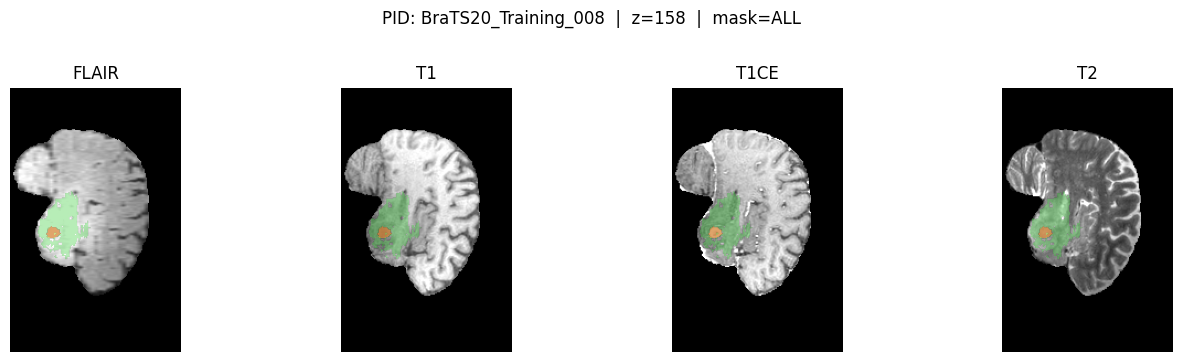

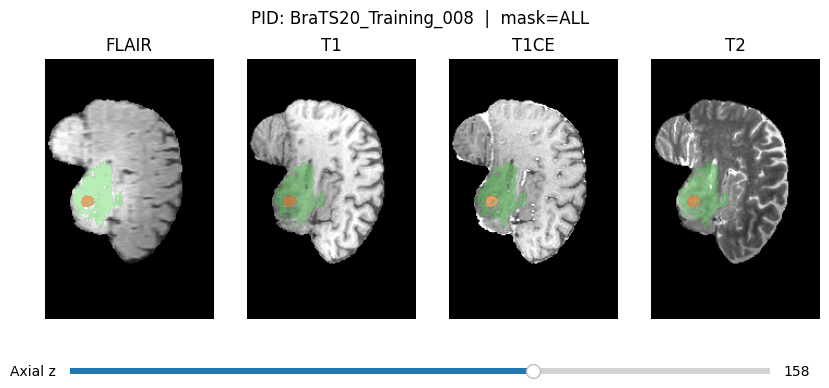

In [13]:
# Ambil sample pertama
case = all_paths[7]     # pastikan all_paths tidak kosong

# Cek ID & file2 yang dipakai (opsional)
print("PID:", case["pid"])
for k in ["flair","t1","t1gd","t2","label"]:
    print(k, "→", case[k])

# Panel statis 4 modalitas + overlay tiga komposit (WT/TC/ET)
show_case_panel(case, which_mask="ALL")   # bisa ganti: "WT", "TC", "ET", atau "ANY"

# Viewer interaktif (slider axial)
interactive_viewer(case, which_mask="ALL")
